# Force-balance analysis of the Cerpa et al. Fluidity subduction model — **mirrored along x**

> **TEST NOTEBOOK.** This is a duplicate of `cerpa_single_step.ipynb` with the model
> mirrored along the x-axis so that subduction matches the MDOODZ convention used
> in the trench_pull_force notebooks: subducting plate on the **right**, plate
> velocity negative (leftward) toward the trench, slab dipping toward the left.
> Coordinate convention is unchanged: x rightward positive, z downward positive.

This notebook diagnoses the **vertically integrated horizontal force balance** in 2D Cerpa-style subduction simulations run with the Fluidity finite-element code. The framework is the same as in the companion repository [`trench_pull_force`](../../trench_pull_force/), where it is applied to MDOODZ7.0 outputs.

**Notebook structure.**

1. Setup & imports
2. Configuration — model, timestep, grid, **mirror flag**
3. Helper functions — field extraction, trench pickers, **mirror operator**
4. Build the regular grid, extract fields, **apply x-mirror**
5. Trench identification (subducting plate on the right after mirror)
6. Vertically integrated traction quantities
7. Trench topography — shear-stress vs free-surface
7B. First isostatic column & 4-panel column profiles
8. Force-balance plots — single timestep
9. Diagnostics
10. Time evolution — loop over timesteps


## 1. Setup & imports

Numerical libraries, PyVista for VTK/PVTU I/O, and minor configuration to silence VTK chatter.


In [156]:
#import pyvista as pv
import numpy as np
import glob
import natsort
import matplotlib.pyplot as plt
import h5py
from scipy.integrate import trapz, cumtrapz
from scipy.ndimage import gaussian_filter
import pyvista as pv
import warnings
import logging
from pathlib import Path

# 1) Redirect VTK C++ error output
pv.set_error_output_file(Path("/tmp/vtk_errors.log"))

# 2) Silence Python logging coming from VTK / PyVista
logging.getLogger("pyvista").setLevel(logging.CRITICAL)
logging.getLogger().setLevel(logging.CRITICAL)

# 3) Silence the Python UserWarning layer
warnings.filterwarnings(
    "ignore",
    message="The VTK reader .*vtkXMLPUnstructuredGridReader.*"
)

plt.rcParams.update({
    "mathtext.fontset": "cm",  
    "font.family": "serif",     
})
import pyvista as pv
#import cmcrameri as cmc

## 2. Configuration

Centralised configuration. Change `MODEL_KEY` to swap between reference models, and `TIMESTEP_INDEX` to load a different snapshot. Grid parameters control the regular grid the PVTU is interpolated onto for vertical integration; both the single-timestep analysis (§4) and the time loop (§9) use these same values.


In [196]:
# === Model selection =========================================================
DATA_ROOT = '/Users/DSAND/DATA/numerical_models/OUTPUTS/'

MODELS = {
    'STD': dict(folder='STD_RefModel', modname='subduction_with_LM'),
    'WAL': dict(folder='WAL_RefModel', modname='subduction_with_LM'),
}

MODEL_KEY      = 'WAL'   # 'STD' or 'WAL'
TIMESTEP_INDEX = 25      # 0-indexed; negative values count from the end (-1 = last)
SECONDS_PER_YEAR = 31_557_600.0   # used for NormalSP::Time -> years conversion

# === Regular-grid parameters (metres) ========================================
DX        = 200.0        # horizontal & vertical grid spacing on the analysis grid
Z_MAX     = 75_000.0    # depth extent
Y_SURFACE = 2_900_000.0  # VTK y-coordinate of the model's free surface

# === Mirror flag =============================================================
# When True, every extracted field is mirrored along x so that subduction
# matches the MDOODZ convention (subducting plate on the right, vx < 0).
# Derived constants below propagate this choice to direction-dependent code.
MIRROR_X        = True
SUBDUCTING_SIDE = "right" if MIRROR_X else "left"
SEAWARD_SIGN    = +1     if MIRROR_X else -1   # use as: tloc + SEAWARD_SIGN * offset_metres

# === Resolved paths ==========================================================
fbase   = DATA_ROOT + MODELS[MODEL_KEY]['folder'] + '/'
modname = MODELS[MODEL_KEY]['modname']

pvtu_files = natsort.natsorted(glob.glob(fbase + modname + '*.pvtu'))
print(f"Model {MODEL_KEY!r}: {len(pvtu_files)} timesteps in {fbase}")
print(f"MIRROR_X = {MIRROR_X}  ->  SUBDUCTING_SIDE = {SUBDUCTING_SIDE!r}, SEAWARD_SIGN = {SEAWARD_SIGN:+d}")


Model 'WAL': 41 timesteps in /Users/DSAND/DATA/numerical_models/OUTPUTS/WAL_RefModel/
MIRROR_X = True  ->  SUBDUCTING_SIDE = 'right', SEAWARD_SIGN = +1


In [197]:
#Y_SURFACE
#tloc

Pick a single timestep for the analysis below.

In [198]:
i = TIMESTEP_INDEX if TIMESTEP_INDEX >= 0 else len(pvtu_files) + TIMESTEP_INDEX
ff = pvtu_files[i]
print(f"Loading timestep {i}: {ff.split('/')[-1]}")
vtk_data = pv.read(ff);


Loading timestep 25: subduction_with_LM_25.pvtu


## 3. Helper functions

- `get_field(name)` — reshapes a PyVista point-data array onto the regular grid and masks invalid samples.
- `find_trench_x(...)` — simple trench picker: coarse pressure-minimum guess plus refined `vx` zero-crossing.
- `pick_trench_3step(...)` — three-stage picker (pressure → velocity → directional pressure search). More robust for snapshots where the surface pressure has multiple local minima; this is the picker used by the time loop.


In [199]:
def get_field(name):
    f = interp[name].reshape((nx_pv, nz_pv), order="F")
    f[~valid] = np.nan
    return f.T        # (z, x)


def mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz):
    """Mirror all 2D fields along x so subduction matches MDOODZ orientation.

    Under the x -> -x reflection (z untouched):
      - scalars and diagonals (p, T, sigma_xx, sigma_zz, fs, vz):  np.flip only
      - off-diagonal stress (sigma_xz) and x-velocity (vx):         np.flip + sign flip
    The x-coordinate array is mirror-symmetric about its midpoint, so it does
    not need to change.
    """
    flip = lambda a: np.flip(a, axis=1)
    return (flip(p), flip(txx), flip(tzz), -flip(txz),
            flip(T), flip(fs), -flip(vx), flip(vz))


def find_trench_x(
    x, z, p, vx,
    z_pick_m=5_000.0,          # use shallow depth for robustness (e.g., 5 km)
    window_km=300.0,           # search window half-width around p-based guess
    smooth_km=20.0,            # smooth vx along x before sign-change search
    require_opposite_sign=True # enforce left<0, right>0 (or vice versa)
):
    """
    Return trench x-location (m) using:
      1) coarse guess from min surface pressure
      2) refined pick from vx sign change near surface inside a window
    """

    # ---- pick depth index to evaluate (nearest to z_pick_m)
    iz = int(np.argmin(np.abs(z - z_pick_m)))
    vx1 = vx[iz, :].copy()
    p1  = p[0, :].copy()  # surface pressure for coarse guess

    # ---- coarse guess from pressure minimum (ignore NaNs)
    j0 = int(np.nanargmin(p1))
    x0 = x[j0]

    # ---- define search window around coarse guess
    W = window_km * 1000.0
    inwin = (x >= x0 - W) & (x <= x0 + W)

    xw = x[inwin]
    vxw = vx1[inwin]

    # ---- smooth vx along x (moving average)
    dx = np.median(np.diff(x))
    k = max(1, int((smooth_km * 1000.0) / dx))
    if k % 2 == 0:
        k += 1
    kernel = np.ones(k) / k
    vxws = np.convolve(vxw, kernel, mode="same")

    # ---- find sign-change locations (zero crossings)
    s = np.sign(vxws)
    s[s == 0] = np.nan
    cross = np.where(np.isfinite(s[:-1]) & np.isfinite(s[1:]) & (s[:-1] * s[1:] < 0))[0]

    if cross.size == 0:
        j = int(np.nanargmin(np.abs(vxws)))
        return xw[j], {"method": "min|vx|", "x0": x0, "iz": iz, "x_window": xw, "vx_window": vxw, "vx_smooth": vxws}

    x_cross = []
    for i in cross:
        x1, x2 = xw[i], xw[i+1]
        v1, v2 = vxws[i], vxws[i+1]
        xc = x1 - v1 * (x2 - x1) / (v2 - v1)
        x_cross.append(xc)
    x_cross = np.array(x_cross)

    if require_opposite_sign:
        keep = []
        for i, xc in zip(cross, x_cross):
            left = vxws[i]
            right = vxws[i+1]
            if np.sign(left) != np.sign(right):
                keep.append(True)
            else:
                keep.append(False)
        keep = np.array(keep, dtype=bool)
        if keep.any():
            x_cross = x_cross[keep]

    jbest = int(np.argmin(np.abs(x_cross - x0)))
    trench_x = float(x_cross[jbest])

    return trench_x, {"method": "vx_zero_cross", "x0": x0, "iz": iz, "x_cross": x_cross,
                      "x_window": xw, "vx_window": vxw, "vx_smooth": vxws}


In [200]:
import numpy as np

def moving_average_1d(y, k):
    if k <= 1:
        return y
    if k % 2 == 0:
        k += 1
    kernel = np.ones(k) / k
    return np.convolve(y, kernel, mode="same")

def first_local_minimum(y, min_prominence=0.0):
    """
    Return index of first local minimum in y.
    """
    for i in range(1, len(y) - 1):
        if y[i] < y[i-1] and y[i] < y[i+1]:
            if min_prominence <= 0:
                return i
            if (max(y[i-1], y[i+1]) - y[i]) >= min_prominence:
                return i
    return None



def pick_pressure_minimum_windowed(
    x, p_row, x_v,
    side="left",          # "left" means x < x_v ; "right" means x > x_v
    W_km=300.0,           # window width on that side
    expected_offset_km=50.0,   # optional bias (trench ~ x_v - 50 km)
    choose="closest_to_expected",  # or "deepest"
    allow_edge=False      # if False, reject minima at window edges
):
    W = W_km * 1000.0
    expected_offset = expected_offset_km * 1000.0

    if side == "left":
        mask = (x < x_v) & (x >= x_v - W)
        x_expected = x_v - expected_offset
    else:
        mask = (x > x_v) & (x <= x_v + W)
        x_expected = x_v + expected_offset

    xw = x[mask]
    pw = p_row[mask]

    if xw.size < 5:
        raise RuntimeError("Step-3 window too small (need >=5 points).")

    # Drop NaNs explicitly (NaNs kill local-min tests)
    good = np.isfinite(pw)
    xw, pw = xw[good], pw[good]
    if xw.size < 5:
        raise RuntimeError("Too many NaNs in step-3 window.")

    # Identify strict local minima (no smoothing)
    # local min if p[i] < p[i-1] and p[i] < p[i+1]
    is_min = (pw[1:-1] < pw[:-2]) & (pw[1:-1] < pw[2:])
    idx = np.where(is_min)[0] + 1   # shift because we tested 1:-1

    if idx.size == 0:
        # Fallback: choose minimum of pw, but it may be an edge point
        j = int(np.argmin(pw))
        return float(xw[j]), {
            "method": "fallback_argmin",
            "x_window": xw, "p_window": pw,
            "x_v": x_v
        }

    # Optionally reject minima too close to window edges
    if not allow_edge:
        idx = idx[(idx > 0) & (idx < len(pw)-1)]
        if idx.size == 0:
            j = int(np.argmin(pw))
            return float(xw[j]), {
                "method": "fallback_argmin_after_edge_reject",
                "x_window": xw, "p_window": pw,
                "x_v": x_v
            }

    # Choose which minimum to use
    if choose == "deepest":
        j = idx[np.argmin(pw[idx])]
        method = "localmin_deepest"
    else:
        # closest to expected x (e.g., x_v - 50 km)
        j = idx[np.argmin(np.abs(xw[idx] - x_expected))]
        method = "localmin_closest_to_expected"

    return float(xw[j]), {
        "method": method,
        "x_window": xw, "p_window": pw,
        "x_candidates": xw[idx],
        "p_candidates": pw[idx],
        "x_expected": x_expected,
        "x_v": x_v
    }

import numpy as np

def pick_trench_3step(
    x, z, p, vx,
    p_depth_m=0.0,            # depth for pressure row (0 -> z[0])
    vx_depth_m=5_000.0,       # depth for velocity diagnostics
    Wp1_km=800.0,             # coarse pressure window
    Wv_km=800.0,              # velocity window
    Wp3_km=300.0,             # FINAL pressure window (directional)
    expected_offset_km=50.0,  # expected trench offset from velocity transition
    smooth_km=20.0,           # smoothing ONLY for velocity
    subducting_side="left"    # "left" or "right" of velocity transition
):
    """
    Three-step non-stateful trench picker:
      1) coarse surface pressure minimum
      2) velocity sign-change (plate boundary)
      3) directional, windowed TRUE pressure minimum
    """

    # ---------------------------
    # Select depth rows
    # ---------------------------
    iz_p  = 0 if p_depth_m == 0.0 else int(np.argmin(np.abs(z - p_depth_m)))
    iz_vx = int(np.argmin(np.abs(z - vx_depth_m)))

    p_row  = p[iz_p, :].copy()
    vx_row = vx[iz_vx, :].copy()

    # ---------------------------
    # STEP 1: coarse pressure minimum
    # ---------------------------
    j0 = int(np.nanargmin(p_row))
    x_p0 = float(x[j0])

    # ---------------------------
    # STEP 2: velocity transition
    # ---------------------------
    # ---------------------------
    # STEP 2: velocity transition
    # ---------------------------
    Wv = Wv_km * 1000.0
    in_v = (x >= x_p0 - Wv) & (x <= x_p0 + Wv)
    
    x_vw  = x[in_v]
    vx_vw = vx_row[in_v]
    
    if x_vw.size < 5:
        raise RuntimeError("Velocity window too small")
    
    # smooth velocity ONLY
    dx = np.median(np.diff(x))
    k = max(1, int((smooth_km * 1000.0) / dx))
    if k % 2 == 0:
        k += 1
    kernel = np.ones(k) / k
    vx_s = np.convolve(vx_vw, kernel, mode="same")
    
    s = np.sign(vx_s)
    s[s == 0] = np.nan
    cross = np.where(
        np.isfinite(s[:-1]) &
        np.isfinite(s[1:]) &
        (s[:-1] * s[1:] < 0)
    )[0]
    
    if cross.size == 0:
        jv = int(np.nanargmin(np.abs(vx_s)))
        x_v = float(x_vw[jv])
        vx_method = "min|vx|"
    else:
        xc = []
        for i in cross:
            x1, x2 = x_vw[i], x_vw[i+1]
            v1, v2 = vx_s[i], vx_s[i+1]
            xc.append(x1 - v1 * (x2 - x1) / (v2 - v1))
        xc = np.array(xc)
    
        # Pick the velocity zero-crossing on the subducting-plate side.
        # Leftmost when the slab descends to the left (subducting_side='left'),
        # rightmost when it descends to the right (subducting_side='right').
        # Symmetric with step 3's directional pressure search; without this
        # branching, mirrored runs lock onto the wrong crossing in snapshots
        # with multiple zero-crossings and the trench jumps landward.
        if subducting_side == "right":
            x_v = float(np.max(xc))
            vx_method = "zero_cross_rightmost"
        else:
            x_v = float(np.min(xc))
            vx_method = "zero_cross_leftmost"

    # ---------------------------
    # STEP 3: directional, windowed TRUE pressure minimum
    # ---------------------------
    Wp3 = Wp3_km * 1000.0
    expected_offset = expected_offset_km * 1000.0

    if subducting_side == "left":
        mask = (x < x_v) & (x >= x_v - Wp3)
        x_expected = x_v - expected_offset
    else:
        mask = (x > x_v) & (x <= x_v + Wp3)
        x_expected = x_v + expected_offset

    xw = x[mask]
    pw = p_row[mask]

    if xw.size < 5:
        raise RuntimeError("Pressure window too small")

    # remove NaNs
    good = np.isfinite(pw)
    xw, pw = xw[good], pw[good]

    if xw.size < 5:
        raise RuntimeError("Too many NaNs in pressure window")

    # TRUE local minima (no smoothing)
    is_min = (pw[1:-1] < pw[:-2]) & (pw[1:-1] < pw[2:])
    idx = np.where(is_min)[0] + 1

    if idx.size == 0:
        # explicit fallback
        j = int(np.argmin(pw))
        trench_x = float(xw[j])
        p_method = "fallback_global_min"
    else:
        # choose minimum closest to expected offset
        j = idx[np.argmin(np.abs(xw[idx] - x_expected))]
        trench_x = float(xw[j])
        p_method = "local_min_windowed"

    # ---------------------------
    # Diagnostics
    # ---------------------------
    info = {
        "x_p0": x_p0,
        "x_v": x_v,
        "trench_x": trench_x,
        "vx_method": vx_method,
        "p_method": p_method,
        "subducting_side": subducting_side,
        "depths_m": {
            "pressure": z[iz_p],
            "velocity": z[iz_vx]
        },
        "windows_km": {
            "Wp1": Wp1_km,
            "Wv": Wv_km,
            "Wp3": Wp3_km
        },
        "debug": {
            "x_vw": x_vw,
            "vx_s": vx_s,
            "xw": xw,
            "pw": pw,
            "x_candidates": xw[idx] if idx.size else None,
            "p_candidates": pw[idx] if idx.size else None
        }
    }

    return trench_x, info


In [201]:
from scipy.ndimage import gaussian_filter1d                                                                                                                                                            
                                                                                                                                                                                                       
                                                                                                                                                                                                         
def find_ridge_x(x, fs_top, tloc, seaward_sign=+1,
                 buffer_km=200, smooth_km=50):                                                                                                                                                         
    """                                                   
    Locate the mid-ocean ridge as the highest point of the free-surface field,
    restricted to columns seaward of the trench.                                                                                                                                                       

    Parameters                                                                                                                                                                                         
    ----------                                            
    x : array, shape (nx,)
        Cell-centred x coordinates [m].                                                                                                                                                                
    fs_top : array, shape (nx,)
        Free-surface elevation (positive up) along the surface row.  Typically                                                                                                                         
        `fs[0, :]` after the x-mirror has been applied.                                                                                                                                                
    tloc : float                                                                                                                                                                                       
        Trench x-location [m].                                                                                                                                                                         
    seaward_sign : {+1, -1}                                                                                                                                                                            
        +1 when the ridge sits at x > tloc (mirrored frame, subducting plate
        on the right).  -1 when it sits at x < tloc (natural frame, subducting                                                                                                                         
        plate on the left).  In your conventions this matches `SEAWARD_SIGN`.
    buffer_km : float                                                                                                                                                                                  
        Skip this much of the outer-rise / forearc immediately seaward of the                                                                                                                          
        trench before searching.  Prevents the local high on the outer-rise                                                                                                                            
        bulge from being confused with the ridge.                                                                                                                                                      
    smooth_km : float                                                                                                                                                                                  
        Light Gaussian smoothing of `fs_top` along x, applied before argmax,                                                                                                                           
        so single-cell spikes can't pose as the ridge.                                                                                                                                                 
                                                                                                                                                                                                       
    Returns                                                                                                                                                                                            
    -------                                                                                                                                                                                            
    x_ridge : float                                       
        Ridge x-location [m].
    i_ridge : int
        Column index of the ridge in `x`.
    """                                                                                                                                                                                                
    DX = float(np.median(np.diff(x)))
                                                                                                                                                                                                       
    sigma_pts = max(1, int(smooth_km * 1000.0 / DX))                                                                                                                                                   
    fs_smooth = gaussian_filter1d(fs_top, sigma=sigma_pts, mode='nearest')
                                                                                                                                                                                                       
    buf_m = buffer_km * 1000.0                                                                                                                                                                         
    if seaward_sign > 0:
        seaward = x > (tloc + buf_m)                                                                                                                                                                   
    else:                                                 
        seaward = x < (tloc - buf_m)
    if not seaward.any():                                                                                                                                                                              
        raise RuntimeError("No columns seaward of trench (after buffer)")
                                                                                                                                                                                                       
    # argmax of the smoothed surface, restricted to seaward columns                                                                                                                                    
    fs_search = np.where(seaward, fs_smooth, -np.inf)
    i_ridge = int(np.argmax(fs_search))                                                                                                                                                                
    return float(x[i_ridge]), i_ridge   

## 4. Build grid and extract fields (single timestep)

Construct a uniform cell-centred grid over `[x_min, x_max] × [0, Z_MAX]` and sample the PVTU onto it. Stress, pressure, temperature, and velocity are extracted as 2D arrays indexed `[z, x]` with depth positive downward.


In [202]:
# === Read PVTU and stash named point-data arrays =============================
vtk_data = pv.read(ff)

vtk_data.point_data["p"]   = vtk_data["NormalSP::Pressure"]
vtk_data.point_data["txx"] = vtk_data["NormalSP::Stress"][:, 0]
vtk_data.point_data["tzz"] = vtk_data["NormalSP::Stress"][:, 4]
vtk_data.point_data["txz"] = -vtk_data["NormalSP::Stress"][:, 1]
vtk_data.point_data["T"]   = vtk_data["NormalSP::Temperature"]
vtk_data.point_data["fs"]  = vtk_data["NormalSP::FreeSurface"]  # surface deflection (m)

vel = vtk_data["NormalSP::Velocity"] / 3.17098e-10  # m/s -> m/yr
vtk_data.point_data["vx"] = vel[:, 0]
vtk_data.point_data["vy"] = vel[:, 1]

# === Define a regular cell-centred analysis grid =============================
x_min, x_max, _, _, _, _ = vtk_data.bounds

nx = int((x_max - x_min) / DX)
nz = int(Z_MAX / DX)

x = x_min + (np.arange(nx) + 0.5) * DX     # metres
z = (np.arange(nz) + 0.5) * DX              # depth, metres (positive down)

X, Z = np.meshgrid(x, z, indexing="xy")
Y    = Y_SURFACE - Z                        # depth -> VTK y

grid = pv.StructuredGrid(X.T, Y.T, np.zeros_like(X.T))

# === Interpolate VTK fields onto the regular grid ============================
interp = grid.sample(vtk_data)

nx_pv, nz_pv, _ = interp.dimensions
valid = interp["vtkValidPointMask"].reshape((nx_pv, nz_pv), order="F").astype(bool)

# === Final canonical-form arrays =============================================
# field[z_index, x_index] lives at (x[x_index], z[z_index])
p   = get_field("p")
txx = get_field("txx")
tzz = get_field("tzz")
txz = get_field("txz")
T   = get_field("T")
vx  = get_field("vx")
vz  = -get_field("vy")            # positive downward
fs  = get_field("fs")             # free-surface deflection (top row only)

# === Apply x-mirror ==========================================================
if MIRROR_X:
    p, txx, tzz, txz, T, fs, vx, vz = mirror_fields_in_x(p, txx, tzz, txz, T, fs, vx, vz)
    print("(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)")

print("x (m):", x[0], "->", x[-1], "  nx =", len(x))
print("z (m):", z[0], "->", z[-1], "  nz =", len(z))
print("p.shape =", p.shape)




(applied x-mirror: subduction now right-to-left, vx < 0 in trailing plate)
x (m): 100.0 -> 7999700.0   nx = 39999
z (m): 100.0 -> 74900.0   nz = 375
p.shape = (375, 39999)


In [203]:
#fs.shape, p.shape

## 5. Trench / Ridge identification

Two pickers are exercised here. The simple one (`find_trench_x`) gives a coarse anchor; the 3-step picker (`pick_trench_3step`) refines it via a directional pressure search on the subducting-plate side.

*This remains the most fragile step in the workflow — see the visual check at the end of the section if a pick looks wrong.*


In [204]:
#surface_p = p[10, :]          # surface row
#ploc = x[np.argmin(surface_p)]

In [205]:
#tloc, info = find_trench_x(x, z, p, vx, z_pick_m=0, window_km=800, smooth_km=1)
#print("trench_x (km):", tloc/1000, "method:", info["method"])

In [206]:
tloc, info = pick_trench_3step(
    x, z, p, vx,
    vx_depth_m=5000,
    Wp1_km=1000,
    Wv_km=800,
    Wp3_km=800,
    smooth_km=40,
    subducting_side=SUBDUCTING_SIDE,
)

tindx = int(np.argmin(np.abs(x - tloc)))

rloc, rindx = find_ridge_x(                                                                                                                                                                  
      x, fs[0, :], tloc,                                    
      seaward_sign=SEAWARD_SIGN,                                                                                                                                                                         
      buffer_km=200, smooth_km=50,
  )


print("Trench (km):", tloc / 1000)
print("Ridge (km):", rloc / 1000)
print("Velocity anchor (km):", info["x_v"] / 1000)
print("Methods:", info["vx_method"], info["p_method"])

Trench (km): 4764.7
Ridge (km): 7479.7
Velocity anchor (km): 4634.40193978363
Methods: zero_cross_rightmost local_min_windowed


(4264.7, 7529.7)

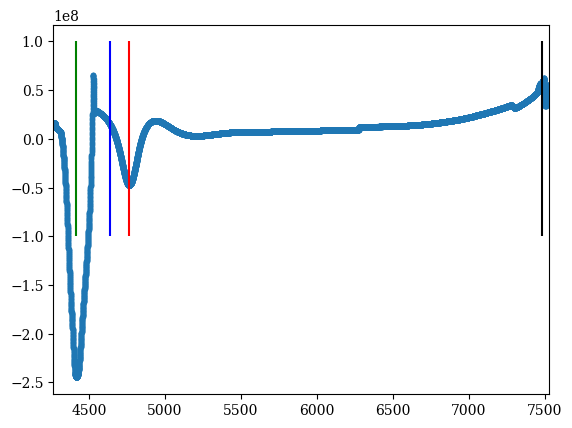

In [207]:
fig, ax = plt.subplots()

ax.plot(x*1e-3 , p[0,:], marker=".")

ax.vlines(tloc*1e-3, 1e8, -1e8, color='r')
ax.vlines(rloc*1e-3, 1e8, -1e8, color='k')

ax.vlines(info["x_p0"]*1e-3, 1e8, -1e8, color='g')
ax.vlines(info["x_v"]*1e-3, 1e8, -1e8, color='b')


ax.set_xlim(tloc*1e-3 - 500, rloc*1e-3 + 50)


## 6. Vertically integrated traction quantities

Compute the depth-integrated quantities that enter the static horizontal force balance:

$$\Delta F_D - \Delta \mathrm{GPE}^* + F_B = 0$$

- $F_D = \overline{\tau_{xx} - \tau_{zz}}$ — in-plane differential stress resultant (tension-like / compression-like).
- $\mathrm{GPE}^* = \overline{p - \tau_{zz}} = -\overline{\sigma_{zz}}$ — pressure-component, carries topographic information including the trench-pull contribution. The constant offset is chosen so $\mathrm{GPE}^*(x_T) = F_D(x_T)$, which makes the curves directly comparable in §8.
- $V = -\overline{\tau_{xz}}$ and $\partial V / \partial x$ — vertical-shear-stress integral. The topography comparison in §7 uses this.
- $F_B$ — cumulative basal traction (referenced to zero at the trench).


In [208]:
from scipy.integrate import cumulative_trapezoid

In [209]:
# These are *resultants* — depth-integrated stress components, not directional                                                                                   
# tractions. A resultant only acquires a signed meaning once paired with the
# outward normal of a chosen plane: V(x) is equal and opposite on the two                                                                                        
# faces of a vertical plane (n̂ = +x̂ vs n̂ = −x̂), by Newton's third law, and
# the same caveat applies to Fd, GPE, and FB. The "right − left for face                                                                                         
# deltas, basal integral oriented left → right" convention used downstream
# in §8 is what closes the signed balance ΔF_D − ΔGPE* + F_B = 0.                                                                                                
                                                                                                                                                                 
Fd   = np.trapz(txx - tzz, z, axis=0)                                                                                                                            
GPE_ = -np.trapz((-p + tzz), z, axis=0)                                                                                                                          
GPE  = GPE_ - GPE_[tindx] + Fd[tindx]                                                                                                                            
V    = np.trapz(txz, z, axis=0)
dVdx = np.gradient(V, x)                                                                                                                                         
                                                                                                                                                                 
# σ_xz at the deepest grid row. Becomes a horizontal basal traction (positive
# in +x̂ when σ_xz > 0) once paired with n̂ = +ẑ — the convention used downstream.                                                                                 
tau_b = txz[-1, :]                                                                                                                                               

# Cumulative basal force per unit out-of-plane length (N/m), referenced to                                                                                       
# zero at the trench. Left-to-right integration matches the right − left
# convention used for the face resultants.                                                                                                                       
FB_ = cumulative_trapezoid(tau_b, x, initial=0.0)         
FB  = FB_ - FB_[tindx] 

In [210]:
FB[tindx]

0.0

## 7. Trench topography — shear-stress support

Trench topography is **non-isostatic**: the deflection isn't supported by density variations within the column, but by horizontal gradients of the vertical shear stress $\tau_{xz}$. Two reconstructions of topography on the seaward side of the trench should agree if that's true:

- **Shear-stress-supported topography** (from the integrated shear-stress gradient):

  $$h_\tau(x) \;=\; -\frac{1}{\rho_m g}\,\frac{\partial V}{\partial x}, \qquad V(x) \;=\; -\!\!\int_0^{z_\mathrm{max}}\!\tau_{xz}(x, z)\,dz$$

- **Actual topography** from the model's `NormalSP::FreeSurface` field at the top row (the surface deflection itself).

Both are referenced to a column $\sim 500$ km seaward of the trench (regional, isostatic). For a non-isostatic feature like the trench the two should overlap.

This anchors the rest of the analysis — the **first isostatic column** seaward of the trench is where the two curves return to zero, i.e. where the shear-stress-supported component has decayed away.


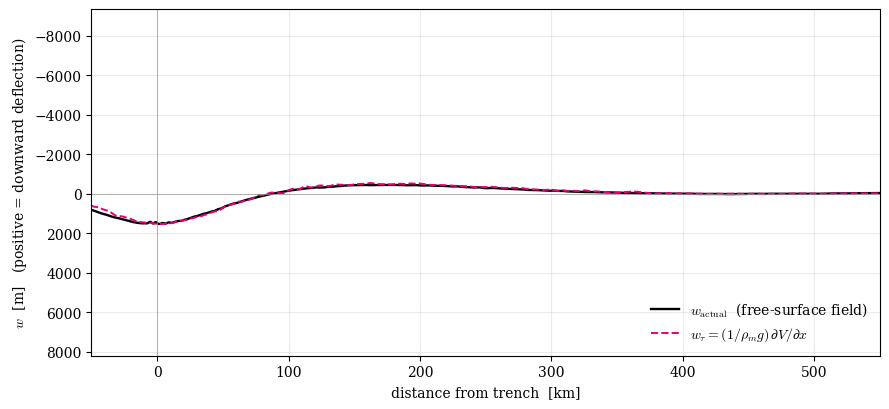

In [211]:
from scipy.ndimage import gaussian_filter1d

# Smooth V before differentiating to clean up grid-scale noise.
# σ in grid points; with DX = 1 km, σ = 10 means 10 km smoothing.
V_smooth = gaussian_filter1d(V, sigma=10, mode="nearest")
dVdx_s   = np.gradient(V_smooth, x)

rho_m, g = 3300.0, 9.8

# Reference column: ~500 km seaward of the trench (regional, isostatic)
x_ref_offset_km = 500
i_ref = int(np.argmin(np.abs(x - (tloc + SEAWARD_SIGN * x_ref_offset_km * 1000))))

# Surface deflection w(x): positive = downward deflection from the regional
# reference at i_ref.  Static-shear balance: ∂V/∂x = ρ_m g · w(x).
w_tau = dVdx_s / (rho_m * g)
w_tau = w_tau - w_tau[i_ref]

# Actual deflection from the free-surface field, top row of the grid.
w_actual = fs[0, i_ref] - fs[0, :]
w_actual = gaussian_filter1d(w_actual, sigma=3, mode="nearest")

xkm_rel = (x - tloc) / 1000.0

fig, ax = plt.subplots(figsize=(9, 4.2))

ax.plot(xkm_rel, w_actual, "k-", lw=1.7,
        label=r"$w_\mathrm{actual}$  (free-surface field)")
ax.plot(xkm_rel, w_tau, color="#E5007D", lw=1.4, ls="--",
        label=r"$w_\tau = (1/\rho_m g)\,\partial V/\partial x$")

ax.axhline(0, color="0.6", lw=0.5)
ax.axvline(0, color="0.6", lw=0.5)

ax.set_xlim(-50, x_ref_offset_km + 50)
ax.set_xlabel("distance from trench  [km]")
ax.set_ylabel(r"$w$  [m]   (positive = downward deflection)")
ax.legend(frameon=False, loc="lower right")
ax.grid(alpha=0.25)
ax.invert_yaxis()

fig.tight_layout()

figures_dir = Path("figures"); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / "trench_topo_shear_vs_pressure.png",
            bbox_inches="tight", dpi=220)
plt.show()


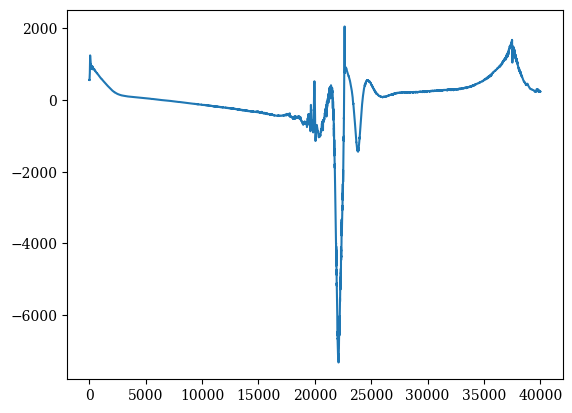

In [212]:
fig, ax = plt.subplots()

ax.plot(fs[0,:])

## 7B. First isostatic column & 4-panel column profiles

Seaward of the trench, $V(x) = -\!\int\!\tau_{xz}\,dz$ peaks (driven by the trench depression's flexural support) and decays back to the regional value across the trailing plate. The **first isostatic column** is the first stationary point of $V$ — equivalently the first zero-crossing of $\partial V/\partial x$ — seaward of the trench. We use it as the trailing-plate anchor for the column-difference figure that follows.

In Cerpa, the subducting plate is on the left, so *seaward* = decreasing $x$. The cell below searches leftward of the trench, within `WINDOW_KM`, for the first sign change in $\partial V/\partial x$. If none is found it falls back to the most-flexed column (max $|V|$).

In [213]:

# Find first isostatic column: first column going seaward from the trench where
# the free surface has recovered to its regional (undeflected) level.
# After x-mirror, "seaward" = increasing x = higher index (trailing plate is on the right).

BUFFER_KM    = 30
WINDOW_KM    = 500
SMOOTH_KM    = 5      # light smoothing on the surface

# Regional-reference column, 500 km seaward of the trench
i_far = int(np.argmin(np.abs(x - (tloc + SEAWARD_SIGN * 500e3))))
h_rel = fs[0, :] - fs[0, i_far]

sigma_grid = max(1, int(SMOOTH_KM * 1000.0 / DX))
h_smooth   = gaussian_filter1d(h_rel, sigma=sigma_grid, mode="nearest")

buffer_grid = int(BUFFER_KM * 1000.0 / DX)
window_grid = int(WINDOW_KM * 1000.0 / DX)

# Walk seaward from the trench (with buffer) and stop where the surface has
# returned to or above regional (h_rel >= 0).  SEAWARD_SIGN sets the direction.
i_start = tindx + SEAWARD_SIGN * buffer_grid
i_end   = tindx + SEAWARD_SIGN * window_grid
i_start = max(0, min(len(x)-1, i_start))
i_end   = max(0, min(len(x)-1, i_end))
step    = SEAWARD_SIGN

xi_indx = None
for i in range(i_start, i_end, step):
    if h_smooth[i] >= 0.0:
        xi_indx = i
        break

if xi_indx is None:
    xi_indx     = i_end
    pick_method = "fallback: end of search window (no topo recovery found)"
else:
    pick_method = f"first topo recovery seaward of trench  (buffer={BUFFER_KM} km, smooth={SMOOTH_KM} km)"

xi_loc  = float(x[xi_indx])
xm_loc  = 0.5 * (tloc + xi_loc)
xm_indx = int(np.argmin(np.abs(x - xm_loc)))

w_T = float(fs[0, xi_indx] - fs[0, tindx])

print(f"x_T = {tloc/1e3:8.1f} km  (tindx  = {tindx})")
print(f"x_I = {xi_loc/1e3:8.1f} km  (xi_indx = {xi_indx},  delta = {(xi_loc - tloc)/1e3:+7.1f} km)")
print(f"x_m = {xm_loc/1e3:8.1f} km  (xm_indx = {xm_indx},  delta = {(xm_loc - tloc)/1e3:+7.1f} km)")
print()
print(f"fs[0, tindx]   = {fs[0, tindx]:+9.1f} m")
print(f"fs[0, xi_indx] = {fs[0, xi_indx]:+9.1f} m")
print(f"w_T = fs[0, xi_indx] - fs[0, tindx] = {w_T:+.1f} m")
print(f"method: {pick_method}")


x_T =   4764.7 km  (tindx  = 23823)
x_I =   4853.1 km  (xi_indx = 24265,  delta =   +88.4 km)
x_m =   4808.9 km  (xm_indx = 24044,  delta =   +44.2 km)

fs[0, tindx]   =   -1435.9 m
fs[0, xi_indx] =    +105.6 m
w_T = fs[0, xi_indx] - fs[0, tindx] = +1541.6 m
method: first topo recovery seaward of trench  (buffer=30 km, smooth=5 km)


In [214]:
2477.4 + 0.5*(2574.9 - 2477.4)

2526.15

/var/folders/50/4pb6cyv53tq0fmpjrm94qgdc0000gn/T/ipykernel_92465/886325856.py:57: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


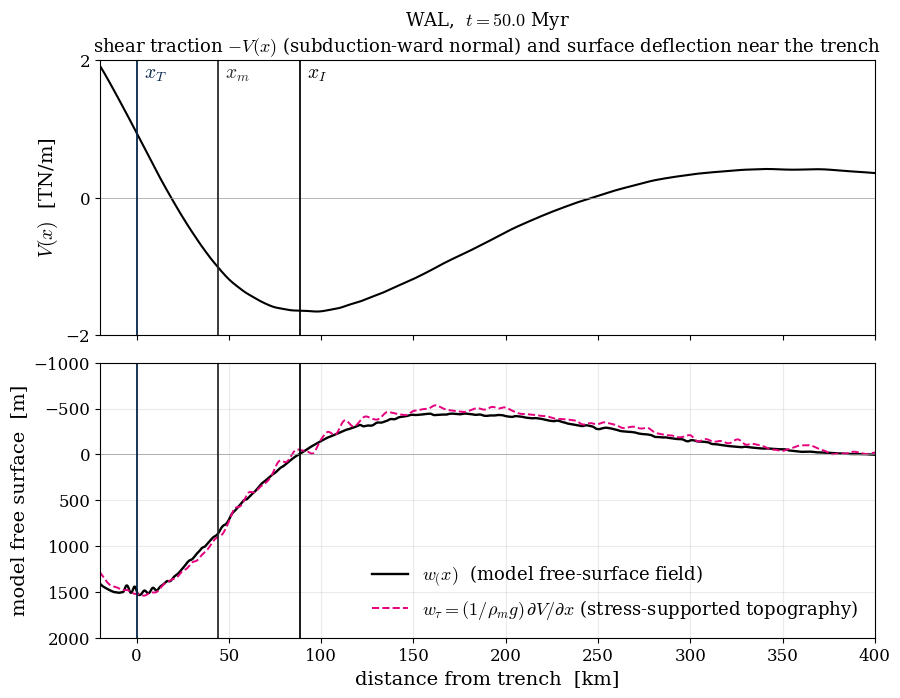

In [215]:
# Top:  shear traction -V(x) on a vertical plane with subduction-ward normal
# Bot:  surface deflection w(x) — model free-surface vs shear-derived
# Both panels plotted against the same x-coordinate (xkm_rel); no masks.

xkm_rel = (x - tloc) * 1e-3
t_yr    = float(np.asarray(vtk_data["NormalSP::Time"]).flat[0]) / SECONDS_PER_YEAR

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7.5), sharex=True,
                               gridspec_kw=dict(hspace=0.10))

# --- top: V(x) -----------------------------------------------------------
ax1.plot(xkm_rel, -V_smooth * 1e-12, "k-", lw=1.5)
ax1.axhline(0, color="0.6", lw=0.5)
ax1.set_ylabel(r"$V(x)$  [TN/m]", fontsize=14)

ax1.set_yticks([-4, -2, 0, 2, 4])
ax1.tick_params(labelsize=12)
ax1.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr\n"
              f"shear traction $-V(x)$ (subduction-ward normal) "
              f"and surface deflection near the trench",
              fontsize=13)

ax1.set_ylim(-2, 2)

# --- bot: surface deflection — both curves on the same xkm_rel, no mask --
ax2.plot(xkm_rel, w_actual, "k-", lw=1.7,
         label=r"$w_(x)$  (model free-surface field)")
ax2.plot(xkm_rel, w_tau, color="#E5007D", lw=1.4, ls="--",
         label=r"$w_\tau = (1/\rho_m g)\,\partial V/\partial x$ (stress-supported topography)")
ax2.axhline(0, color="0.6", lw=0.5)
ax2.set_xlabel("distance from trench  [km]", fontsize=14)
ax2.set_ylabel(r"model free surface  [m]", fontsize=14)
ax2.legend(frameon=False, loc="lower right", fontsize=13)
ax2.tick_params(labelsize=12)
ax2.grid(alpha=0.25)
ax2.set_ylim(-1000, 2000)
ax2.invert_yaxis()

# Column lines on both panels.  Labels at top of ax1, offset right of each line.
columns = [
    (tloc,       r"$x_T$",  "#002147"),
    (xi_loc,     r"$x_I$",  "k"),
    (x[xm_indx], r"$x_m$",  "0.15"),
]
for x_col, label, color in columns:
    xrel = (x_col - tloc) * 1e-3
    for ax_ in (ax1, ax2):
        ax_.axvline(xrel, color=color, lw=1.4, alpha=0.9)
    ax1.annotate(label, xy=(xrel, 1), xycoords=("data", "axes fraction"),
                 xytext=(5, -4), textcoords="offset points",
                 ha="left", va="top", color=color,
                 fontsize=14, fontweight="bold")

# Trench-anchored window — x_T = 0 stays visible at every timestep
ax1.set_xlim(-20, 400)

fig.tight_layout()

figures_dir = Path("figures"); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f"w_actual_vs_w_tau_{MODEL_KEY}_t{TIMESTEP_INDEX}.png",
            bbox_inches="tight", dpi=220)
plt.show()

### Four-panel column profiles

Mirroring `profiles.png` from `trench_pull_force/model_analysis/figures/`. Three columns are sampled: the trench column $x_T$, the first isostatic column $x_I$, and their midpoint $x_m$. Both $x_T$ and $x_I$ are smoothed over $\pm 10\;DX$ to suppress single-column noise.

- **(a)** $\tau_{xx}-\tau_{zz}$ at $x_m$, with twin top-axis showing $T(z)$
- **(b)** $\tau_{xz}$ at $x_m$
- **(c)** column difference $\Delta\sigma_{zz}(z) = \sigma_{zz}(x_I, z) - \sigma_{zz}(x_T, z)$. Shaded area between the curve and zero, integrated to compensation, is the trench-pull contribution. Dashed line marks the analytical scaling $-(\rho_m - \rho_w)\,g\,w_T$ (with $\rho_w = 0$ for the no-water Cerpa setup).
- **(d)** cumulative $\Delta\mathrm{GPE}^*(z) = -\!\int_0^z(\sigma_{zz}^{(I)} - \sigma_{zz}^{(T)})\,dz'$ in TN/m. Should plateau at the regional offset by compensation depth.

The Cerpa pressure is dynamic (lithostatic subtracted), but for a column **difference** the lithostatic part cancels, so $\Delta\sigma_{zz}$ from the model output is directly comparable to the analytical scaling.

In [177]:
#z_np_km, w_T, delrho, rho_m 

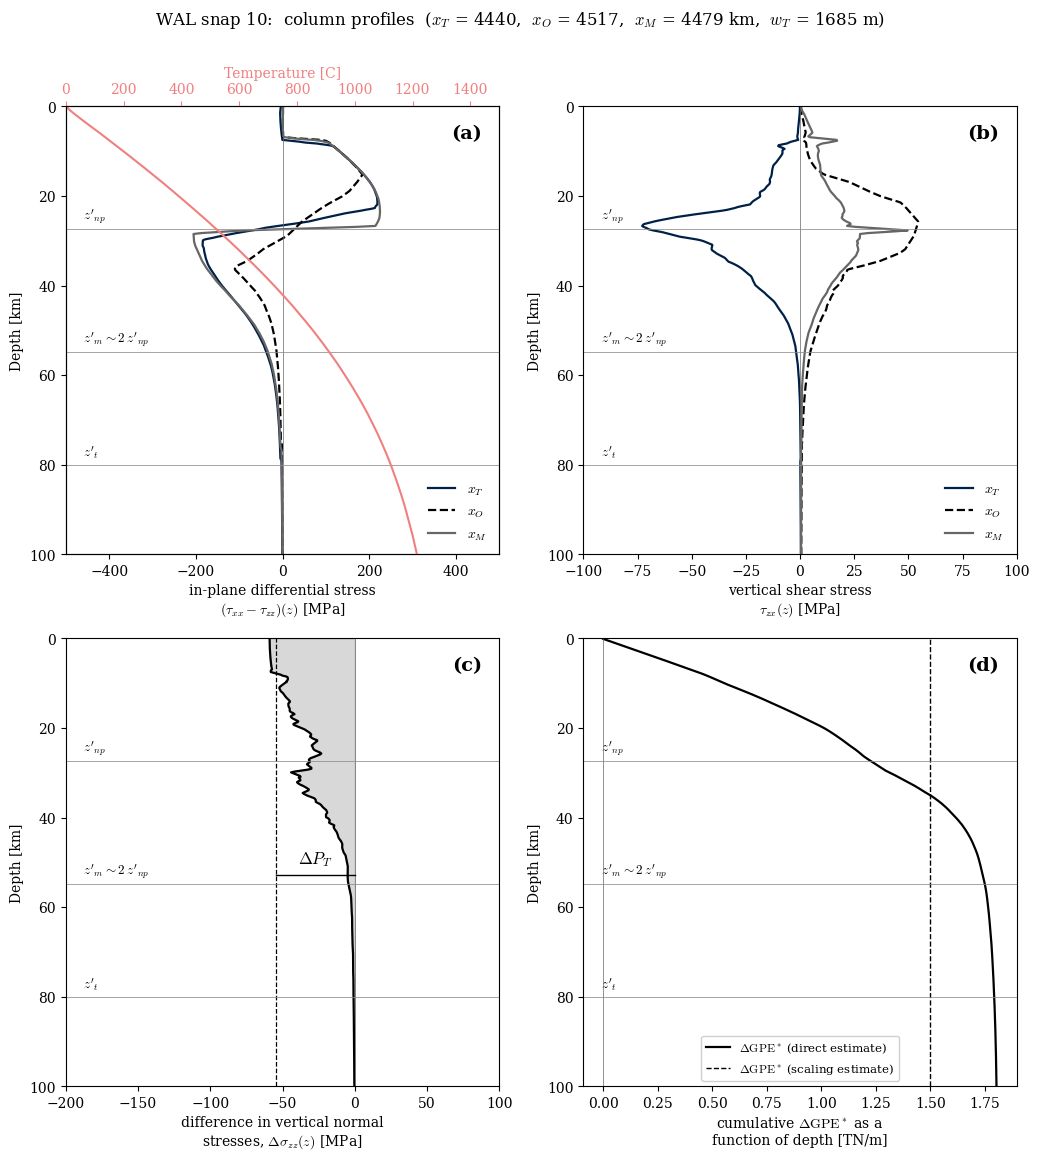

In [178]:
# 4-panel column-profile figure (mirrors trench_pull_force/profiles.png).
# No masks; domain set with xlim. w_T is the simple free-surface difference.
#
# Changes in this version:
#   - all four panels are fully framed (top/right spines kept)
#   - three column traces in (a) and (b) are differentiated by colour + linestyle,
#     with a legend; column labels switched to x_O / x_T / x_M

SMOOTHWIN = 1                          # +/- grid columns to average around picked columns
RHO_W     = 0.0                         # Cerpa: no water above the surface

# Style for the three column traces.  x_O replaces x_I in this figure's labelling.
COL_STYLES = {
    "T": dict(color="#002147", ls="-",  lw=1.6, label=r"$x_T$"),   # trench
    "O": dict(color="k",       ls="--", lw=1.6, label=r"$x_O$"),   # outer reference
    "M": dict(color="0.4",     ls="-",  lw=1.6, label=r"$x_M$"),   # midpoint
}

# sigma_zz = -p + tau_zz  (Cerpa pressure is dynamic; lithostatic part cancels in column diff)
sig_zz = -p + tzz

def col_avg(arr, ix, win=SMOOTHWIN):                                                                                                                                                                 
    """Average over [ix-win, ix+win] along the last (x) axis.
    Works for 1D (depth-integrated) or 2D (z, x) arrays."""                                                                                                                                          
    lo, hi = max(0, ix - win), min(arr.shape[-1] - 1, ix + win)                                                                                                                                      
    return arr[..., lo:hi+1].mean(axis=-1)     

sig_zz_T     = col_avg(sig_zz, tindx)
sig_zz_I     = col_avg(sig_zz, xi_indx)
delta_sig_zz = sig_zz_I - sig_zz_T
delta_GPE_z  = -cumulative_trapezoid(delta_sig_zz, z, initial=0.0)

# w_T was set in the find-iso cell
delrho   = rho_m - RHO_W
ref_line = -delrho * g * w_T            # Pa (analytical Delta-sigma_zz scaling)

# Neutral plane: zero-crossing of (tau_xx - tau_zz) at x_M, between 10 and 50 km depth
diff_xm = txx[:, xm_indx] - tzz[:, xm_indx]
z_lo, z_hi = 10e3, 50e3
i_zlo = int(np.argmin(np.abs(z - z_lo)))
i_zhi = int(np.argmin(np.abs(z - z_hi)))
sc = []
for k in range(i_zlo, i_zhi):
    if diff_xm[k] * diff_xm[k+1] < 0:
        sc.append(k)
if len(sc) > 0:
    k = sc[0]
    z_np = z[k] - diff_xm[k] * (z[k+1] - z[k]) / (diff_xm[k+1] - diff_xm[k])
else:
    z_np = 30e3
z_np_km = z_np / 1e3
z_m_km  = 2 * z_np_km
z_t_km  = 80.0
gpe_est = abs(ref_line) * z_np

z_lines = [
    (z_np_km, r"$z'_{np}$"),
    (z_m_km,  r"$z'_m \sim 2\,z'_{np}$"),
    (z_t_km,  r"$z'_t$"),
]

DEPTH_LIM = (100, 0)

fig, axs = plt.subplots(2, 2, figsize=(10.5, 11.5))
ax_a, ax_b = axs[0]
ax_c, ax_d = axs[1]

T_COLOR = "#F08080"

# (a) tau_xx - tau_zz  +  Temperature twin axis
ax_a.plot((txx[:, tindx]   - tzz[:, tindx])   * 1e-6, z*1e-3, **COL_STYLES["T"])
ax_a.plot((txx[:, xi_indx] - tzz[:, xi_indx]) * 1e-6, z*1e-3, **COL_STYLES["O"])
ax_a.plot((txx[:, xm_indx] - tzz[:, xm_indx]) * 1e-6, z*1e-3, **COL_STYLES["M"])
ax_a.legend(frameon=False, loc="lower right", fontsize=10)

ax_a.axvline(0, color="0.4", lw=0.5)
ax_a.set_xlim(-500, 500)
ax_a.set_ylim(*DEPTH_LIM)
ax_a.set_ylabel("Depth [km]")
ax_a.set_xlabel("in-plane differential stress\n" + r"$(\tau_{xx} - \tau_{zz})(z)$ [MPa]")
ax_aT = ax_a.twiny()
ax_aT.plot(T[:, xm_indx] - 273, z*1e-3, color=T_COLOR, lw=1.5)
ax_aT.set_xlim(0, 1500)
ax_aT.set_xlabel("Temperature [C]", color=T_COLOR)
ax_aT.tick_params(axis="x", colors=T_COLOR)

# (b) tau_xz at the three columns
ax_b.plot(txz[:, tindx]   * 1e-6, z*1e-3, **COL_STYLES["T"])
ax_b.plot(txz[:, xi_indx] * 1e-6, z*1e-3, **COL_STYLES["O"])
ax_b.plot(txz[:, xm_indx] * 1e-6, z*1e-3, **COL_STYLES["M"])
ax_b.legend(frameon=False, loc="lower right", fontsize=10)
ax_b.axvline(0, color="0.4", lw=0.5)
ax_b.set_xlim(-100, 100)
ax_b.set_ylim(*DEPTH_LIM)
ax_b.set_ylabel("Depth [km]")
ax_b.set_xlabel("vertical shear stress\n" + r"$\tau_{zx}(z)$ [MPa]")

# (c) Delta sigma_zz column difference
ax_c.plot(delta_sig_zz * 1e-6, z*1e-3, "k-", lw=1.6)
ax_c.fill_betweenx(z*1e-3, 0, delta_sig_zz * 1e-6,
                   where=(delta_sig_zz < 0), color="0.7", alpha=0.5)
ax_c.axvline(0, color="0.4", lw=0.5)
ax_c.axvline(ref_line * 1e-6, color="k", ls="--", lw=0.9)
ax_c.set_xlim(-200, 100)
ax_c.set_ylim(*DEPTH_LIM)
ax_c.set_ylabel("Depth [km]")
ax_c.set_xlabel("difference in vertical normal\n" + r"stresses, $\Delta\sigma_{zz}(z)$ [MPa]")
z_lab = z_m_km - 2
ax_c.plot([ref_line * 1e-6, 0], [z_lab, z_lab], "k-", lw=1.0)
ax_c.text(0.5 * ref_line * 1e-6, z_lab - 1.5, r"$\Delta P_T$",
          ha="center", va="bottom", fontsize=12)

# (d) cumulative Delta GPE*
ax_d.plot(delta_GPE_z * 1e-12, z*1e-3, "k-", lw=1.6,
          label=r"$\Delta\mathrm{GPE}^*$ (direct estimate)")
ax_d.axvline(0, color="0.4", lw=0.5)
ax_d.axvline(gpe_est * 1e-12, color="k", ls="--", lw=1.0,
             label=r"$\Delta\mathrm{GPE}^*$ (scaling estimate)")
ax_d.set_ylim(*DEPTH_LIM)
ax_d.set_ylabel("Depth [km]")
ax_d.set_xlabel("cumulative $\\Delta\\mathrm{GPE}^*$ as a\nfunction of depth [TN/m]")
ax_d.legend(loc="lower center", frameon=True, fontsize=8.5, framealpha=0.92)

# Panel labels and z'-depth guides — all four panels are kept fully framed
panel_labels = [(ax_a, "(a)"), (ax_b, "(b)"), (ax_c, "(c)"), (ax_d, "(d)")]
for ax_, lbl in panel_labels:
    ax_.text(0.96, 0.96, lbl, transform=ax_.transAxes, ha="right", va="top",
             fontsize=14, fontweight="bold")
    for zz, _ in z_lines:
        ax_.axhline(zz, color="0.55", lw=0.55)
    xlo, xhi = ax_.get_xlim()
    for zz, lbl_z in z_lines:
        ax_.text(xlo + 0.04*(xhi - xlo), zz - 1.0, lbl_z,
                 ha="left", va="bottom", fontsize=9.5)

fig.suptitle(f"{MODEL_KEY} snap {TIMESTEP_INDEX}:  column profiles  "
             f"($x_T$ = {tloc/1e3:.0f},  $x_O$ = {xi_loc/1e3:.0f},  $x_M$ = {x[xm_indx]/1e3:.0f} km,  $w_T$ = {w_T:.0f} m)",
             y=1.005)
fig.tight_layout()

fig.savefig(figures_dir / f"profiles_{MODEL_KEY}_t{TIMESTEP_INDEX}.png",
            bbox_inches="tight", dpi=200)
plt.show()


In [179]:
# Neutral plane: zero-crossing of (tau_xx - tau_zz) at x_M, between 10 and 50 km depth
#diff_xm = txx[:, xm_indx] - tzz[:, xm_indx]
diff_xm = txx[:, tindx] - tzz[:, tindx]

z_lo, z_hi = 10e3, 50e3
i_zlo = int(np.argmin(np.abs(z - z_lo)))
i_zhi = int(np.argmin(np.abs(z - z_hi)))
sc = []
for k in range(i_zlo, i_zhi):
    if diff_xm[k] * diff_xm[k+1] < 0:
        sc.append(k)
if len(sc) > 0:
    k = sc[0]
    z_np = z[k] - diff_xm[k] * (z[k+1] - z[k]) / (diff_xm[k+1] - diff_xm[k])
else:
    z_np = 30e3
z_np_km = z_np / 1e3
print(z_np_km)

26.564443449202066


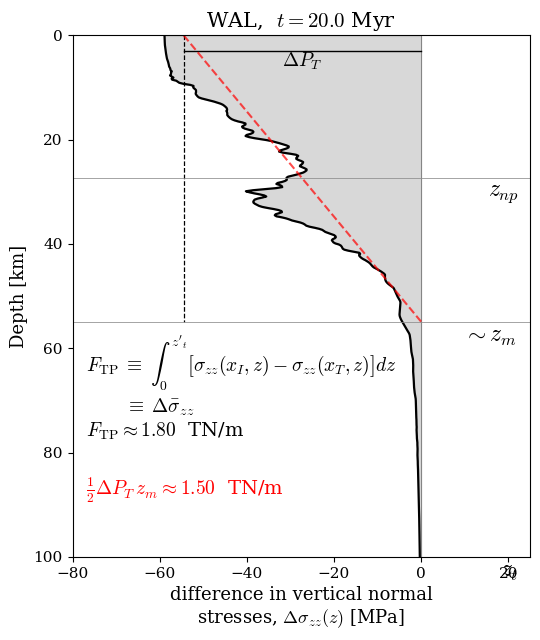

In [180]:
# Standalone panel (c) — Δσ_zz that defines the trench pull force.
# Faithful copy of panel (c) from the 4-panel figure (with ΔP_T dashed line,
# bracket, and z'_np / z'_m / z'_t horizontal markers preserved), plus three
# extra annotations for the talk slide:
#   - lower-left equation box, including the bar-averaged form
#   - upper-right column-definitions box
#   - shading limited to the integration depth (visualises the integral)

DEPTH_LIM = (100, 0)
SMOOTHWIN = 10
COMPENSATION_DEPTH_KM = 100
RHO_W = 0.0

# --- Recompute the column quantities --------------------------------------
sig_zz       = -p + tzz
sig_zz_T     = col_avg(sig_zz, tindx,   win=SMOOTHWIN)
sig_zz_I     = col_avg(sig_zz, xi_indx, win=SMOOTHWIN)
delta_sig_zz = sig_zz_I - sig_zz_T

# Analytical Δσ_zz scaling at compensation depth (the trench-pressure deficit ΔP_T)
delrho   = rho_m - RHO_W
ref_line = -delrho * g * w_T

# Neutral plane z'_np, mechanical thickness z'_m ≈ 2 z'_np, compensation z'_t
diff_xm = txx[:, xm_indx] - tzz[:, xm_indx]
i_zlo, i_zhi = int(np.argmin(np.abs(z - 10e3))), int(np.argmin(np.abs(z - 50e3)))
sc = [k for k in range(i_zlo, i_zhi) if diff_xm[k] * diff_xm[k+1] < 0]
z_np    = (z[sc[0]] - diff_xm[sc[0]] * (z[sc[0]+1] - z[sc[0]]) /
           (diff_xm[sc[0]+1] - diff_xm[sc[0]])) if sc else 30e3
z_np_km = z_np / 1e3
z_m_km  = 2 * z_np_km
z_t_km  = COMPENSATION_DEPTH_KM

z_lines = [
    (z_np_km, r"$z_{np}$"),
    (z_m_km,  r"$\sim z_m$ "),
    (z_t_km,  r"$z_t$"),
]

# Trench pull force from the direct integral, plus the bar-averaged form
i_zt    = int(np.argmin(np.abs(z - z_t_km * 1e3)))
F_TP    = -np.trapz(delta_sig_zz[:i_zt+1], z[:i_zt+1])
F_TP_TN = F_TP * 1e-12
F_TP_SR = 1e-12*(-ref_line*1e3*z_m_km*1/2)

# --- Figure ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(5.5, 6.5))

ax.plot(delta_sig_zz * 1e-6, z*1e-3, "k-", lw=1.6)

# Shading limited to the integration depth so the shaded area visually IS F_TP
ax.fill_betweenx(z[:i_zt+1] * 1e-3, 0, delta_sig_zz[:i_zt+1] * 1e-6,
                 where=(delta_sig_zz[:i_zt+1] < 0), color="0.7", alpha=0.5)

# Zero reference and the ΔP_T scaling line (analytical Δσ_zz at compensation)
ax.axvline(0, color="0.4", lw=0.5)
#ax.axvline(ref_line * 1e-6,  color="k", ls="--", lw=0.9)
ax.plot([ref_line * 1e-6, ref_line * 1e-6], [0, z_m_km],                                                                                                                                             
          color="k", ls="--", lw=0.9)  

ax.set_xlim(-80, 25)
ax.set_ylim(*DEPTH_LIM)
ax.set_xlabel("difference in vertical normal\n"
              + r"stresses, $\Delta\sigma_{zz}(z)$ [MPa]", fontsize=13)
ax.set_ylabel("Depth [km]", fontsize=13)
ax.tick_params(labelsize=11)

# ΔP_T bracket and label (horizontal connector at z_lab between -ΔP_T and 0)

z_lab = 3.0                                                                                                                                                                                         
ax.plot([ref_line * 1e-6, 0], [z_lab, z_lab], "k-", lw=1.0)
ax.text(0.5 * ref_line * 1e-6, z_lab + 4, r"$\Delta P_T$",                                                                                                                                         
          ha="center", va="bottom", fontsize=14) 

# Horizontal markers and labels at z'_np, z'_m, z'_t
xlo, xhi = ax.get_xlim()                   
for zz, lbl_z in z_lines:
    ax.axhline(zz, color="0.55", lw=0.55)                                                                                                                                                            
    ax.text(xhi - 0.025*(xhi - xlo), zz + 5.0, lbl_z,                                                                                                                                                 
              ha="right", va="bottom", fontsize=17)

# --- Equation box (lower-left) — integral AND bar-averaged form ----------
eq_text = (                                                                                                                                                                                          
    r"$F_\mathrm{TP}\;\equiv\;\int_0^{z'_t}"
    r"\left[\sigma_{zz}(x_I,z) - \sigma_{zz}(x_T,z)\right] dz$"                                                                                                                                      
    "\n"                                                  
    r"$\quad\quad\;\equiv\;\Delta\bar\sigma_{zz}$"                                                                                                                                                   
    f"\n$F_\\mathrm{{TP}} \\approx {F_TP_TN:.2f}$  TN/m"                                                                                                                                             
)                                                                                                                                                                                                    
ax.text(0.03, 0.22, eq_text, transform=ax.transAxes,                                                                                                                                                 
        fontsize=14, ha="left", va="bottom")
                                                                                                                                                                                                     
# Scaling-relation line — red, placed just above the equation box                                                                                                                                    
ax.text(0.03, 0.1,
        rf"$\frac{{1}}{{2}}\Delta P_T\,z_m \approx {F_TP_SR:.2f}$  TN/m",                                                                                                                           
        transform=ax.transAxes, color="red",                                                                                                                                                         
        fontsize=14, ha="left", va="bottom")


# --- Column-definitions box (upper-right) --------------------------------
#ax.text(
#    0.97, 0.97,
#    r"$x_T$ : trench column" + "\n"
#    r"$x_I$ : first isostatic column",
#    transform=ax.transAxes,
#    fontsize=10, va="top", ha="right",
#    bbox=dict(boxstyle="round,pad=0.45", facecolor="white",
#              edgecolor="0.7", lw=0.6, alpha=0.95),
#)

ax.plot([ref_line*1e-6 , 0], 
        [0, z_m_km], c = "r", ls = "--", alpha = 0.7)

ax.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr", fontsize=15)

fig.tight_layout()

fig.savefig(figures_dir / f"trench_pull_definition_{MODEL_KEY}_t{TIMESTEP_INDEX}.png",
            bbox_inches="tight", dpi=220)
plt.show()

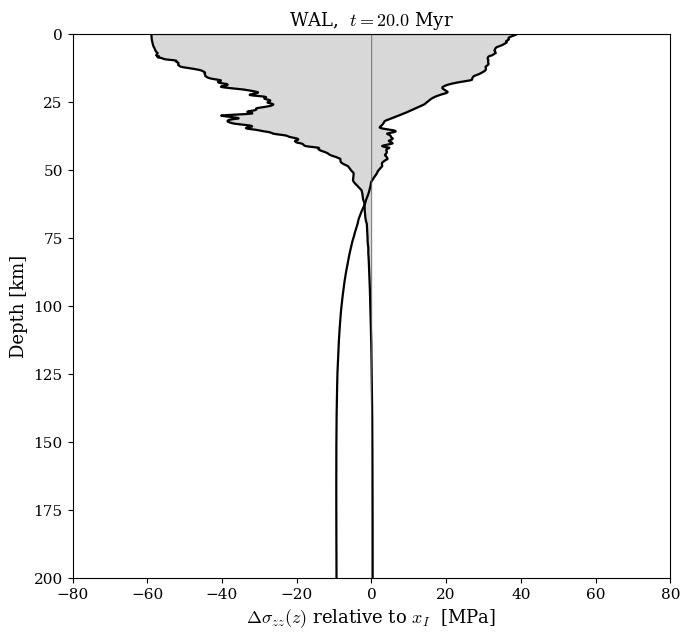

In [181]:
# Stripped Δσ_zz panel — both trench-pull and ridge-push deltas referenced
# to the first isostatic column x_I.
#
# delta_TP = σ_zz(x_I) - σ_zz(x_T)   (negative — plots on the left)
# delta_RP = σ_zz(x_I) - σ_zz(x_R)   (positive — plots on the right)
#
# Same I-as-reference subtractor for both terms, so x_I sits at zero, the
# trench-column lobe leans left, and the ridge-column lobe leans right.
#
# Assumes find_ridge_x is defined as a helper (the function from the
# previous step) and SEAWARD_SIGN is in scope.

DEPTH_LIM             = (200, 0)
SMOOTHWIN             = 10
COMPENSATION_DEPTH_KM = 200

# --- Locate the ridge ----------------------------------------------------
ridge_loc, ridge_indx = find_ridge_x(
    x, fs[0, :], tloc, seaward_sign=SEAWARD_SIGN,
    buffer_km=200, smooth_km=50,
)

# --- Column averages of σ_zz at the three reference columns --------------
sig_zz   = -p + tzz
sig_zz_T = col_avg(sig_zz, tindx,     win=SMOOTHWIN)
sig_zz_I = col_avg(sig_zz, xi_indx,   win=SMOOTHWIN)
sig_zz_R = col_avg(sig_zz, ridge_indx, win=SMOOTHWIN)

delta_TP = sig_zz_I - sig_zz_T            # < 0   trench column lighter
delta_RP = sig_zz_I - sig_zz_R            # > 0   ridge  column heavier

i_zt = int(np.argmin(np.abs(z - COMPENSATION_DEPTH_KM * 1e3)))

# --- Figure --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 6.5))

# Trench-pull lobe (negative)
ax.plot(delta_TP * 1e-6, z*1e-3, "k-", lw=1.6)
ax.fill_betweenx(z[:i_zt+1] * 1e-3, 0, delta_TP[:i_zt+1] * 1e-6,
                 where=(delta_TP[:i_zt+1] < 0), color="0.7", alpha=0.5)

# Ridge-push lobe (positive)
ax.plot(delta_RP * 1e-6, z*1e-3, "k-", lw=1.6)
ax.fill_betweenx(z[:i_zt+1] * 1e-3, 0, delta_RP[:i_zt+1] * 1e-6,
                 where=(delta_RP[:i_zt+1] > 0), color="0.7", alpha=0.5)

ax.axvline(0, color="0.4", lw=0.5)

ax.set_xlim(-80, 80)
ax.set_ylim(*DEPTH_LIM)
ax.set_xlabel(r"$\Delta\sigma_{zz}(z)$ relative to $x_I$  [MPa]", fontsize=13)
ax.set_ylabel("Depth [km]", fontsize=13)
ax.tick_params(labelsize=11)

ax.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr", fontsize=13)



fig.tight_layout()
plt.show()


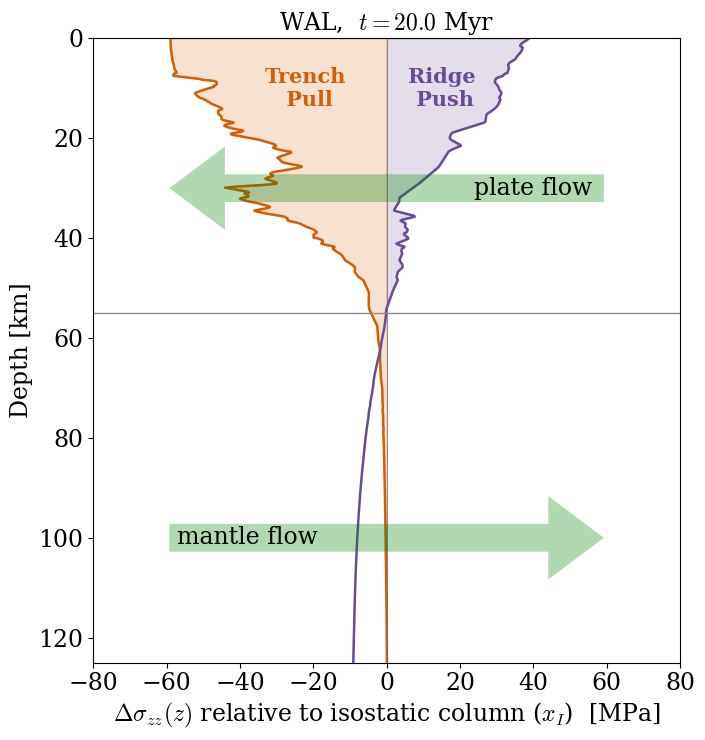

In [191]:
# Δσ_zz panel — trench-pull (left) and ridge-push (right) deltas referenced
# to the first isostatic column x_I, with two opaque arrows illustrating the
# lithospheric and asthenospheric flow directions and a "decoupling" band
# between them.
#
# delta_TP = σ_zz(x_I) - σ_zz(x_T)   (negative — left, navy)
# delta_RP = σ_zz(x_I) - σ_zz(x_R)   (positive — right, magenta)
#
# Assumes find_ridge_x is defined as a helper and SEAWARD_SIGN is in scope.

DEPTH_LIM             = (125, 0)
SMOOTHWIN             = 1
COMPENSATION_DEPTH_KM = 150

# Decoupling band depths (km)
DECOUPLING_TOP_KM = 50
DECOUPLING_BOT_KM = 70

# Flow-illustration arrow depths (km)
LITHO_ARROW_Z_KM = 30
ASTH_ARROW_Z_KM  = 100

# Curve colours
COLOR_TP = "#002147"   # navy   — trench-pull side
COLOR_RP = "#E5007D"   # magenta — ridge-push side

COLOR_TP = "#D55E00"                                                                                              
COLOR_RP =  "#6A4C93"                                                                                                            
                                                             

# --- Locate the ridge ----------------------------------------------------
ridge_loc, ridge_indx = find_ridge_x(
    x, fs[0, :], tloc, seaward_sign=SEAWARD_SIGN,
    buffer_km=200, smooth_km=50,
)

# --- Column averages of σ_zz at the three reference columns --------------
sig_zz   = -p + tzz
sig_zz_T = col_avg(sig_zz, tindx,     win=SMOOTHWIN)
sig_zz_I = col_avg(sig_zz, xi_indx,   win=SMOOTHWIN)
sig_zz_R = col_avg(sig_zz, ridge_indx, win=SMOOTHWIN)

delta_TP = sig_zz_I - sig_zz_T            # < 0   trench column lighter
delta_RP = sig_zz_I - sig_zz_R            # > 0   ridge  column heavier

i_zt = int(np.argmin(np.abs(z - COMPENSATION_DEPTH_KM * 1e3)))

# --- Figure --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7.5))

# Decoupling band — sits behind everything else


#ax.axhspan(DECOUPLING_TOP_KM, DECOUPLING_BOT_KM,
#           color="0.85", alpha=0.6, zorder=0)
#ax.text(78, 0.5 * (DECOUPLING_TOP_KM + DECOUPLING_BOT_KM),
#        "decoupling", ha="right", va="center",
#        fontsize=11, color="0.3", style="italic", zorder=1)

# Trench-pull lobe (negative, navy)
ax.plot(delta_TP * 1e-6, z * 1e-3, color=COLOR_TP, lw=1.8)
ax.fill_betweenx(z[:i_zt+1] * 1e-3, 0, delta_TP[:i_zt+1] * 1e-6,
                 where=(delta_TP[:i_zt+1] < 0),
                 color=COLOR_TP, alpha=0.18)

# Ridge-push lobe (positive, magenta)


ax.plot(delta_RP * 1e-6, z * 1e-3, color=COLOR_RP, lw=1.8)
#ax.plot(delta_RP * 1e-6 + 10, z * 1e-3, color=COLOR_RP, lw=1.8, ls= "--")
ax.fill_betweenx(z[:i_zt+1] * 1e-3, 0, delta_RP[:i_zt+1] * 1e-6,
                 where=(delta_RP[:i_zt+1] > 0),
                 color=COLOR_RP, alpha=0.18)

ax.axvline(0, color="0.4", lw=0.5)

ARROW_KW = dict(                                                                                                                                                                                       
      arrowstyle="simple,head_length=1.0,head_width=1.5,tail_width=0.5",
      color="green", lw=0, alpha=0.3, mutation_scale=40,                                                                                                                                                 
  )

# Lithospheric flow — left                                                                                                                                                                             
ax.annotate("", xy=(-60, LITHO_ARROW_Z_KM), xytext=(60, LITHO_ARROW_Z_KM),
              arrowprops=ARROW_KW, zorder=10)                                                                                                                                                            
                                                            
# Asthenospheric counter-flow — right                                                                                                                                                                  
ax.annotate("", xy=(60, ASTH_ARROW_Z_KM), xytext=(-60, ASTH_ARROW_Z_KM),
              arrowprops=ARROW_KW, zorder=10) 


#ax.axhline(z_np_km, color="0.55", lw=0.55) 
ax.axhline(z_m_km, color="0.55", lw=1) 

# Region labels — sit inside their respective lobes                                                                                                                                                    
ax.text( 15, 10, "Ridge\n Push",                                                                                                                                                                        
         color=COLOR_RP, fontsize=15, fontweight="bold",                                                                                                                                               
         ha="center", va="center", zorder=11)                                                                                                                                                          
ax.text(-22, 10, "Trench\n Pull",                          
         color=COLOR_TP, fontsize=15, fontweight="bold",                                                                                                                                               
         ha="center", va="center", zorder=11)                                                                                                                                                          

# Flow labels — caption the two arrows                                                                                                                                                                 
ax.text(40, LITHO_ARROW_Z_KM , "plate flow",                             
        color="black", fontsize=17,                                                                                                                                                 
        ha="center", va="center", zorder=11)
ax.text(-38, ASTH_ARROW_Z_KM, "mantle flow",                                                                                                                                                                         
          color="black", fontsize=17,    
          ha="center", va="center", zorder=11)   


ax.set_xlim(-80, 80)
ax.set_ylim(*DEPTH_LIM)
ax.set_xlabel(r"$\Delta\sigma_{zz}(z)$ relative to isostatic column ($x_I$)  [MPa]", fontsize=17)
ax.set_ylabel("Depth [km]", fontsize=17)
ax.tick_params(labelsize=17)

ax.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr", fontsize=17)

fig.tight_layout()
figures_dir = Path("figures"); figures_dir.mkdir(exist_ok=True)                                                                                                                                        
fig.savefig(figures_dir / f"trench_ridge_delta_sigma_zz_{MODEL_KEY}_t{TIMESTEP_INDEX}.png",
              bbox_inches="tight", dpi=220) 

plt.show()

# Note — pressure-gradient decoupling between lithosphere and asthenospheric counter-flow


## Observation

As the integration depth `z_c` is taken progressively deeper, a systematic and persistent pressure offset emerges between the column beneath the ridge and the column beneath the trench (or just landward of the trench). The offset becomes resolvable at roughly **z > 70 km** and asymptotes to a roughly constant value or 10 MPa at ~ 100 km.

## Two-flows interpretation

There are **two co-existing flows**, each driven by its own horizontal pressure gradient:

1. **Lithospheric flow** — in the model frame, the subducting plate moves *toward the trench*. The pressure gradient driving this is **ridge → trench** (high to low). This is the conventional ridge-push picture, with the gradient confined to the cold, strong upper part of the lithosphere.

2. **Asthenospheric counter-flow** — mass conservation under a downwelling slab requires return flow *toward the ridge*. Driving this requires the **opposite** gradient: **trench → ridge**. The deeper, weaker asthenosphere supplies it.

The two gradients are not just different in magnitude — they are **opposite in sign**. They live in different depth intervals (lithosphere on top, asthenosphere below) and drive different layers in different directions.

## The cancellation problem

If the analysis is done as a single cumulative depth integral of the horizontal pressure gradient, both contributions are summed indiscriminately. The result is:

- Shallow depths only — you measure the **lithospheric** (ridge → trench) driving gradient. Sign positive in the convention here.
- Deeper integration — you start adding the **asthenospheric** (trench → ridge) gradient. Sign negative.
- Take the integral all the way through — the two contributions tend to cancel, and the integrated horizontal force on a vertical column appears to vanish.

That cancellation is real arithmetic but a misleading physical picture. It would lead a reader to conclude "nothing is driving anything", when in fact two independent driving gradients are doing real and opposing work in two depth intervals.

## Stress continuity: the two flows aren't fully decoupled

The two-flows picture is the right zeroth-order story, but the flows are **not** kinematically independent. They are coupled through stress continuity at their shared interface (effectively the lithosphere–asthenosphere boundary, or wherever the horizontal shear rate beneath the plate is maximum — the depth of kinematic decoupling in the conventional sense). At that depth:

- The horizontal pressure gradient is **already** non-zero — and it's already the *adverse* (trench → ridge) gradient that drives the asthenospheric counter-flow.
- That gradient acts at the *base* of the overlying lithosphere, which experiences a different horizontal pressure gradient at its *top* (the ridge → trench gradient). The plate is therefore subject to a mismatch in horizontal pressure between its top and its base.
- The mismatch tilts the plate. The lithosphere doesn't just translate — it inclines, so that the base of the strong layer is no longer parallel to the surface.
- The tilt itself contributes a horizontal force component on the plate, oriented **opposite** to ridge push.

Net effect: ridge push, as observed in these 2D models, is **systematically reduced** relative to the textbook ρgΔh estimate. The upper boundary layer is pushed one way by its own gradient and partially tilted back by the dynamics of the lower boundary layer trying to maintain incompressibility. Crucially, the tilt is not a parasitic side-effect — it is *part of* the mechanism by which the asthenospheric pressure asymmetry is set up in the first place. Tilting the plate's base is what creates the tilted upper boundary of the asthenospheric flow region, which is what allows pressure to drive return flow back to the ridge. The two flows need each other.

Practically, this means the "decoupling" advocated in the previous section is partial. Integrating the lithospheric and asthenospheric depth ranges separately gives you the right *book-keeping*, but the values you read off are not independent — they're coupled through the geometry of the tilted plate.

## Implication

Any force-balance treatment of this system needs an **explicit decoupling** of the lithospheric and asthenospheric pressure-gradient contributions — for example by integrating the two depth ranges separately and reporting them as separate terms, rather than collapsing them into a single column integral. Without that decoupling, the framework hides the very mechanism it should expose.

Practically, this argues for a fixed integration depth `z_c` chosen *just below* the brittle/strong lithosphere base and *above* the asthenospheric counter-flow regime — i.e. at the depth where the lithospheric contribution has already integrated out but the asthenospheric one hasn't yet started. In Cerpa runs this looks to sit around 60–100 km; the precise number is a property of the run's thermal/rheological structure and worth quantifying explicitly when doing this analysis on other models.

Note (per the stress-continuity caveat above) that the resulting "lithospheric ridge push" measured this way is *not* the textbook ρgΔh value — it is reduced by the back-tilt induced by the asthenospheric counter-flow. Reporting the reduction explicitly (textbook ridge push minus measured ridge push, or the ratio) is probably the cleanest way to convey what the model is actually doing.

## Pointers (where this shows up in the current notebooks)

- The trench-and-ridge Δσ_zz panel (`cerpa_trench_ridge_delta_sigma_zz.py`) makes the offset visible: shallow part of the curves (small z) shows the lithospheric gradient; deeper part shows the asthenospheric counter-gradient.
- The trench-pull definition figure integrates only to `z_c ≈ 80–100 km` and so captures essentially the lithospheric contribution alone, by construction.
- A natural next step is a *second* trench-pull-style figure that isolates the asthenospheric contribution — Δσ_zz integrated from `z_c` downward, showing the equal-and-opposite force.

In [143]:
#sig_zz_I - sig_zz_R =>NEG
#P_I - P_R => positive
#
#P_R- P_I => neg (at depth_)
#consisitent with a long wavelnegtgh counterflow

In [144]:
#60e6*100e3*1e-12
#z_m_km, ref_line
F_TP * 1e-12
1e-12*(-ref_line*1e3*z_m_km*1/2)

1.6436375003108494

/var/folders/50/4pb6cyv53tq0fmpjrm94qgdc0000gn/T/ipykernel_92465/1501867187.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='lower left', frameon=False, fontsize=10)


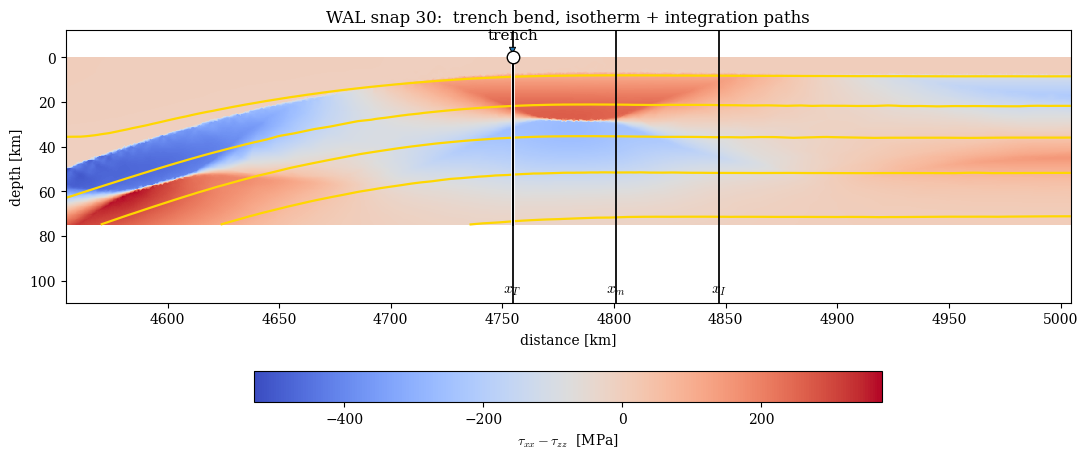

In [145]:
WIN_X_KM = 200
WIN_Z_KM = 110
x_lo_v = tloc - WIN_X_KM * 1e3
x_hi_v = tloc + 250e3
ix_v   = (x >= x_lo_v) & (x <= x_hi_v)

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.pcolormesh(x[ix_v]*1e-3, z*1e-3,                                                                                                                                                             
                     (txx[:, ix_v] - tzz[:, ix_v]) * 1e-6,    # Pa -> MPa
                     cmap='coolwarm', shading='auto')            

cbar = fig.colorbar(im, ax=ax,                            
                      label=r'$\tau_{xx} - \tau_{zz}$  [MPa]',                                                                                                                                         
                      orientation='horizontal', fraction=0.06, pad=0.13)

ax.contour(x[ix_v]*1e-3, z*1e-3, T[:, ix_v], levels=[400, 600, 800, 1000, 1200],
           colors='gold', linewidths=1.6)



# Vertical integration line
ax.plot([tloc*1e-3, tloc*1e-3], [z[0]*1e-3, z[-1]*1e-3],
        color='white', lw=2.6)
ax.plot([tloc*1e-3, tloc*1e-3], [z[0]*1e-3, z[-1]*1e-3],
        color='black', lw=1.4)


# Trench marker
ax.plot(tloc*1e-3, 0, 'wo', mec='k', ms=9, zorder=5)
ax.annotate('trench', xy=(tloc*1e-3, 0), xytext=(tloc*1e-3, -8),
            ha='center', fontsize=11,
            arrowprops=dict(arrowstyle='-|>', lw=0.7))

ax.invert_yaxis()
ax.set_xlim(x_lo_v*1e-3, x_hi_v*1e-3)
ax.set_ylim(WIN_Z_KM, -12)
ax.set_xlabel('distance [km]')
ax.set_ylabel('depth [km]')
ax.set_aspect('equal')
ax.legend(loc='lower left', frameon=False, fontsize=10)
ax.set_title(f'{MODEL_KEY} snap {TIMESTEP_INDEX}:  trench bend, isotherm + integration paths')


# Three column lines on both panels
columns = [
    (tloc,         r'$x_T$',  'k'),
    (xi_loc,       r'$x_I$',  'k'),
    (x[xm_indx],   r'$x_m$',  'k'),
]
for x_col, label, color in columns:
    xrel = (x_col) * 1e-3
    ax.axvline(xrel, color=color, lw=1.4, alpha=0.9)
    ax.annotate(label, xy=(xrel, 0), xycoords=('data', 'axes fraction'),
                 xytext=(0, 4), textcoords='offset points',
                 ha='center', va='bottom', color=color, fontsize=11, fontweight='bold')


fig.tight_layout()




#figures_dir = Path('figures'); figures_dir.mkdir(exist_ok=True)                                                                                                                                      
#fig.savefig(figures_dir / f'diff_stress_isotherms_{MODEL_KEY}_t{TIMESTEP_INDEX}.png',
#              bbox_inches='tight', dpi=200)
#plt.show()

## 8. Force balance — single timestep

Two views of the trailing-plate force balance at the chosen snapshot. The first omits $\mathrm{GPE}^*$ to highlight the residual; the second shows all three terms together. The dashed green curve is the residual $\Delta F_D - \Delta \mathrm{GPE}^* + F_B$ — should be small everywhere if the integrals close.


In [146]:
#500*3300*9.8*1e-6
#col_avg(Sxx[:], tindx)
#WIN_T

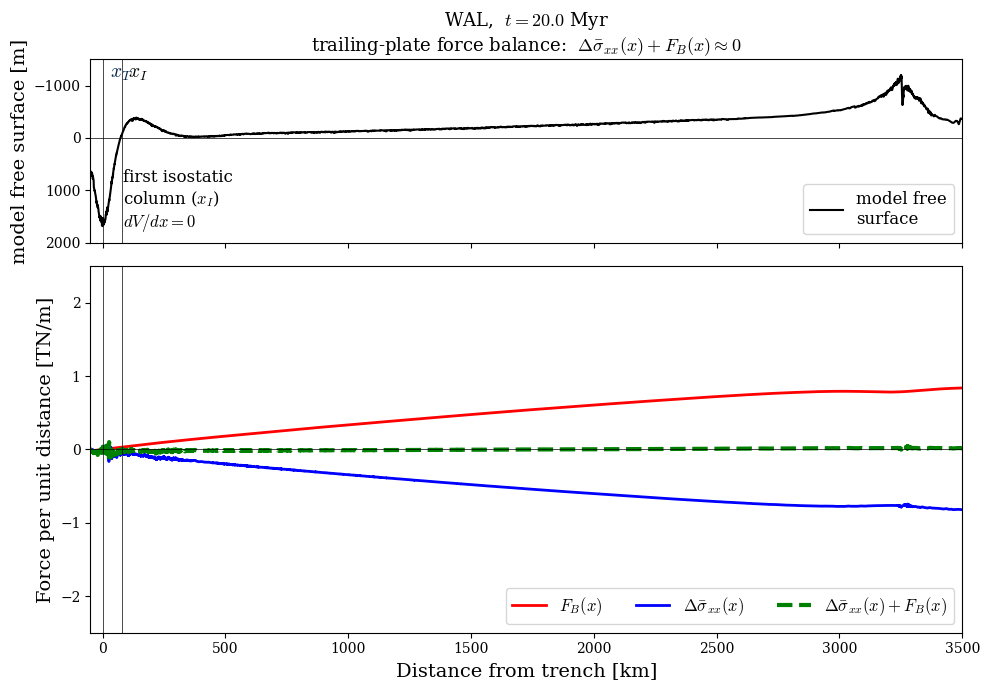

In [192]:
# § 8.1b — Boring form of the force balance, with topography panel
#                                                                                                                                                                                                    
#   Delta Sigma_xx(x) + F_B(x) ~ 0                        
#                                                                                                                                                                                                    
# Two-panel: model free surface (top), boring force balance (bottom).
# In the mirrored frame, deltas are referenced to a ±N km window around x_T.                                                                                                                         
                                                                                                                                                                                                     
# Trench-reference window: average ±N km around the picked trench column.                                                                                                                            
TRENCH_REF_HW_KM = 10                                  # half-width in km                                                                                                                            
WIN_T = max(1, int(TRENCH_REF_HW_KM * 1000 / DX))      # in grid points
                                                                                                                                                                                                     
Sxx       = np.trapz(-p + txx, z, axis=0)              # int sigma_xx dz                                                                                                                             
delta_Sxx = Sxx - col_avg(Sxx, tindx, win=WIN_T)                                                                                                                                                     
                                                                                                                                                                                                     
xkm = (x - tloc) * 1e-3                                   
                                                                                                                                                                                                     
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,                                                                                                                                   
                                gridspec_kw={"height_ratios": [1, 2]})
                                                                                                                                                                                                     
# --- Top: model free surface (positive = downward deflection) ---                                                                                                                                   
ax1.plot(xkm, -fs[0, :], color="k", lw=1.5, alpha=1,
         label="model free\nsurface")                                                                                                                                                                
                                                          
ax1.axhline(0, color="k", lw=0.5)                                                                                                                                                                    
ax1.axvline(0, color="k", lw=0.5)
ax1.axvline((xi_loc - tloc) * 1e-3, color="k", lw=0.5)                                                                                                                                               
ax1.set_ylim(2000, -1500)                       # inverted: deflection down +ve                                                                                                                      
ax1.set_ylabel("model free surface [m]", fontsize=14)
ax1.legend(loc="lower right", fontsize=12)                                                                                                                                                           
ax1.text((xi_loc - tloc) * 1e-3 + 5, 1700,                
         "first isostatic\ncolumn (" + r"$x_I$" + ")\n" + r"$dV/dx = 0$",                                                                                                                            
         fontsize=12)                                     
                                                                                                                                                                                                     
# x_T / x_I labels along the top of the top panel         
for x_col, label, color in [(tloc,  r"$x_T$", "#002147"),                                                                                                                                            
                            (xi_loc, r"$x_I$", "k")]:                                                                                                                                                
    xrel = (x_col - tloc) * 1e-3
    ax1.annotate(label, xy=(xrel, 1), xycoords=("data", "axes fraction"),                                                                                                                            
                 xytext=(5, -4), textcoords="offset points",
                 ha="left", va="top", color=color,                                                                                                                                                   
                 fontsize=14, fontweight="bold")          
                                                                                                                                                                                                     
# --- Bottom: boring form, Delta Sxx + F_B ~ 0 ---                                                                                                                                                   
ax2.plot(xkm, FB         * 1e-12, color="red", lw=2,
         label=r"$F_B(x)$")                                                                                                                                                                          
ax2.plot(xkm, delta_Sxx  * 1e-12, color="b",   lw=2,                                                                                                                                                 
         label=r"$\Delta\bar\sigma_{xx}(x)$")
ax2.plot(xkm, (delta_Sxx + FB) * 1e-12,                                                                                                                                                              
         color="g", ls="--", lw=3,                        
         label=r"$\Delta\bar\sigma_{xx}(x) + F_B(x)$")                                                                                                                                               
                                                          
ax2.axhline(0, color="k", lw=0.5)                                                                                                                                                                    
ax2.axvline(0, color="k", lw=0.5)                         
ax2.axvline((xi_loc - tloc) * 1e-3, color="k", lw=0.5)                                                                                                                                               
ax2.set_xlabel("Distance from trench [km]", fontsize=14)
ax2.set_ylabel("Force per unit distance [TN/m]", fontsize=14)                                                                                                                                        
ax2.set_xlim(-50, 3500)                                   
ax2.set_ylim(-2.5, 2.5)                                                                                                                                                                              
ax2.legend(loc="lower right", fontsize=12, ncol=3)        
                                                                                                                                                                                                     
ax1.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr\n"                                                                                                                                            
              r"trailing-plate force balance:  "
              r"$\Delta\bar\sigma_{xx}(x) + F_B(x) \approx 0$",                                                                                                                                      
              fontsize=13)                                                                                                                                                                           
 
fig.tight_layout()                                                                                                                                                                                   
fig.savefig(figures_dir / f"force_balance_xx_FB_topo_{MODEL_KEY}_t{TIMESTEP_INDEX}.png",
            bbox_inches="tight", dpi=220)                                                                                                                                                            
plt.show()

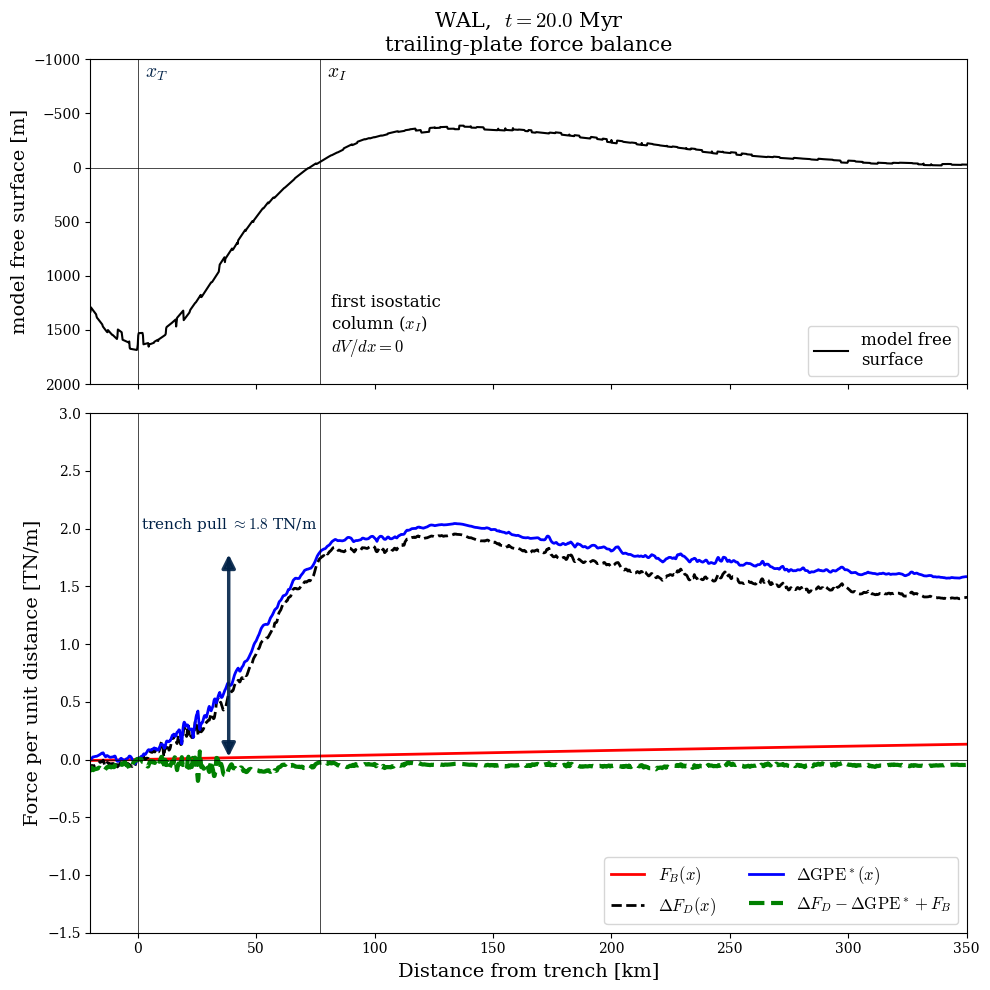

In [193]:
# § 8.2 — Interesting form of the force balance, with topography panel
#
#   Delta F_D(x) - Delta GPE*(x) + F_B(x) ~ 0
#
# In the mirrored frame, the natural deltas are (current - trench).

Sxx = np.trapz(-p + txx, z, axis=0)     # int sigma_xx dz
Szz = np.trapz(-p + tzz, z, axis=0)     # int sigma_zz dz   (= -GPE*)

#delta_Fd  = Fd  - Fd[tindx]
#delta_Szz = Szz - Szz[tindx]            # = -Delta GPE*  (we plot this directly)

# Trench-reference window: average ±N km around the picked trench column.                                                                                                                            
TRENCH_REF_HW_KM = 1                                  # half-width in km                                                                                                                            
WIN_T = max(1, int(TRENCH_REF_HW_KM * 1000 / DX))      # in grid points                                                                                                                              
                                                                                                                                                                                        
delta_Fd = Fd  -  col_avg(Fd, tindx, win=WIN_T)
delta_Szz = Szz - col_avg(Szz,  tindx, win=WIN_T)


# Pseudo-topography from V's gradient, aligned to actual at x_I
topo_actual     = fs[0, :]
topo_pseudo     = -dVdx / (rho_m * g)
topo_pseudo_ref = topo_pseudo - topo_pseudo[xi_indx] - topo_actual[xi_indx]

xkm = (x - tloc) * 1e-3

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True,
                                gridspec_kw={"height_ratios": [1.25, 2]})

# --- Top: topography ---
# --- Top: model free surface (positive = downward deflection) ---                                                                                                                                 
ax1.plot(xkm, -fs[0, :], color="k", lw=1.5, alpha=1,                                                                                                                                               
         label="model free\nsurface")                                                                                                                                                              
                                                                                                                                                                                                   
ax1.axhline(0, color="k", lw=0.5)                                                                                                                                                                  
ax1.axvline(0, color="k", lw=0.5)
ax1.axvline((xi_loc - tloc)*1e-3, color="k", lw=0.5)                                                                                                                                               
ax1.set_ylim(2000, -1000)                       # was (-2000, 1000)                                                                                                                                
ax1.set_ylabel("model free surface [m]", fontsize=14)
ax1.legend(loc="lower right", fontsize=12)      # ncol=2 dropped — only one curve                                                                                                                  
ax1.text((xi_loc - tloc)*1e-3 + 5, 1700,        # was y = -1700                                                                                                                                    
           "first isostatic\ncolumn (" + r"$x_I$" + ")\n" + r"$dV/dx = 0$",                                                                                                                          
           fontsize=12)  

# --- Bottom: ΔF_D - ΔGPE* + F_B ---
ax2.plot(xkm, FB         * 1e-12, color="red", lw=2,
         label=r"$F_B(x)$")
ax2.plot(xkm, delta_Fd   * 1e-12, color="k", ls="--", lw=2,
         label=r"$\Delta F_D(x)$")
ax2.plot(xkm, -delta_Szz  * 1e-12, color="b", lw=2,
         label=r"$\Delta\mathrm{GPE}^*(x)$")
ax2.plot(xkm, (delta_Fd + delta_Szz + FB) * 1e-12,
         color="g", ls="--", lw=3,
         label=r"$\Delta F_D - \Delta\mathrm{GPE}^* + F_B$")

################
# Trench pull force scale: ΔGPE* between x_T and x_I, drawn as an arrow at x_M.                                                                                                                      
TRENCH_PULL_TN = 1.8                   
xM_rel_km = (x[xm_indx] - tloc) * 1e-3                                                                                                                                                               
ax2.annotate("", xy=(xM_rel_km, TRENCH_PULL_TN), xytext=(xM_rel_km, 0),                                                                                                                              
               arrowprops=dict(arrowstyle="<|-|>", color="#002147",                                                                                                                                      
                               lw=2.5, mutation_scale=20, alpha=0.9)) 

ax2.text(xM_rel_km, TRENCH_PULL_TN + 0.15,                                                                                                                                                           
           r"trench pull $\approx %.1f$ TN/m" % TRENCH_PULL_TN,
           color="#002147", fontsize=11, ha="center", va="bottom")
#################


ax2.axhline(0, color="k", lw=0.5)
ax2.axvline(0, color="k", lw=0.5)
ax2.axvline((xi_loc - tloc)*1e-3, color="k", lw=0.5)
ax2.set_xlabel("Distance from trench [km]", fontsize=14)
ax2.set_ylabel("Force per unit distance [TN/m]", fontsize=14)
ax2.set_xlim(-20, 350)
ax2.set_ylim(-1.5, 3.0)
ax2.legend(loc="lower right", fontsize=12, ncol=2)
ax1.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr\n"                                                                                                                                            
                r"trailing-plate force balance"                                                                                                                                                     ,
                fontsize=15)
for x_col, label, color in [(tloc, r"$x_T$", "#002147"),                                                                                                                                             
                              (xi_loc, r"$x_I$", "k")]:     
    xrel = (x_col - tloc) * 1e-3                                                                                                                                                                     
    ax1.annotate(label, xy=(xrel, 1), xycoords=("data", "axes fraction"),
                   xytext=(5, -4), textcoords="offset points",                                                                                                                                         
                   ha="left", va="top", color=color,        
                   fontsize=14, fontweight="bold")

fig.savefig(figures_dir / f"force_balance_FD_GPE_FB_{MODEL_KEY}_t{TIMESTEP_INDEX}.png",                                                                                                              
              bbox_inches="tight", dpi=220)

fig.tight_layout()
plt.show()


In [149]:
FB[tindx]

0.0

 ## § 8.3 — Plotting the absolute value of $F_D$   


  The previous panel shows the three-term balance                                                                                                                                                      
   
  $$\Delta F_D(x) \;-\; \Delta\mathrm{GPE}^*(x) \;+\; F_B(x) \;\approx\; 0$$                                                                                                                           
                                                                                                                                                                                                       
  with every term anchored to zero at $x_T$. That makes the *shape* of the balance easy to read, but loses the *absolute* value of $F_D$ — the quantity that has a direct physical interpretation for 
  any single column.                                                                                                                                                                                   
                                                            
  Expanding the delta operator,                                                                                                                                                                        
                                                                                                                                                                                                       
  $$\Delta F_D(x) \;=\; F_D(x) \;-\; F_D(x_T),$$
                                                                                                                                                                                                       
  and absorbing the constant $-F_D(x_T)$ into the GPE bracket gives an equivalent rearrangement:
                                                                                                                                                                                                       
  $$F_D(x) \;-\; \Big[\Delta\mathrm{GPE}^*(x) \;+\; F_D(x_T)\Big] \;+\; F_B(x) \;\approx\; 0 \;.$$
                                                                                                                                                                                                       
  Algebraically this is identical to the previous form: the same constant $F_D(x_T)$ is added to one term and subtracted from another, so the closure is unchanged. What we gain is interpretive — 
  $F_D(x)$ is now plotted at its **true value**, not relative to the trench. That value carries an objective physical meaning for any single lithospheric column:                                      
                                                            
  - $F_D(x) > 0$ — the column is **tension-like**: the depth-integrated $\tau_{xx}-\tau_{zz}$ acts in the $+x$ direction.                                                                              
  - $F_D(x) < 0$ — the column is **compression-like**.      
                                                                                                                                                                                                       
  Within the bending slab, both senses coexist over depth (extension above the neutral plane, compression below). $F_D$ is the depth-averaged resultant, not a pointwise statement about every depth.  
                                                                                                                                                                                                       
  The re-referenced GPE term $\Delta\mathrm{GPE}^*(x) + F_D(x_T)$ inherits $F_D(x_T)$ as its baseline: far from the trench, where $\Delta\mathrm{GPE}^*(x)\to 0$, it asymptotes to $F_D(x_T)$ rather   
  than to zero.  

In [150]:
WIN_T

5

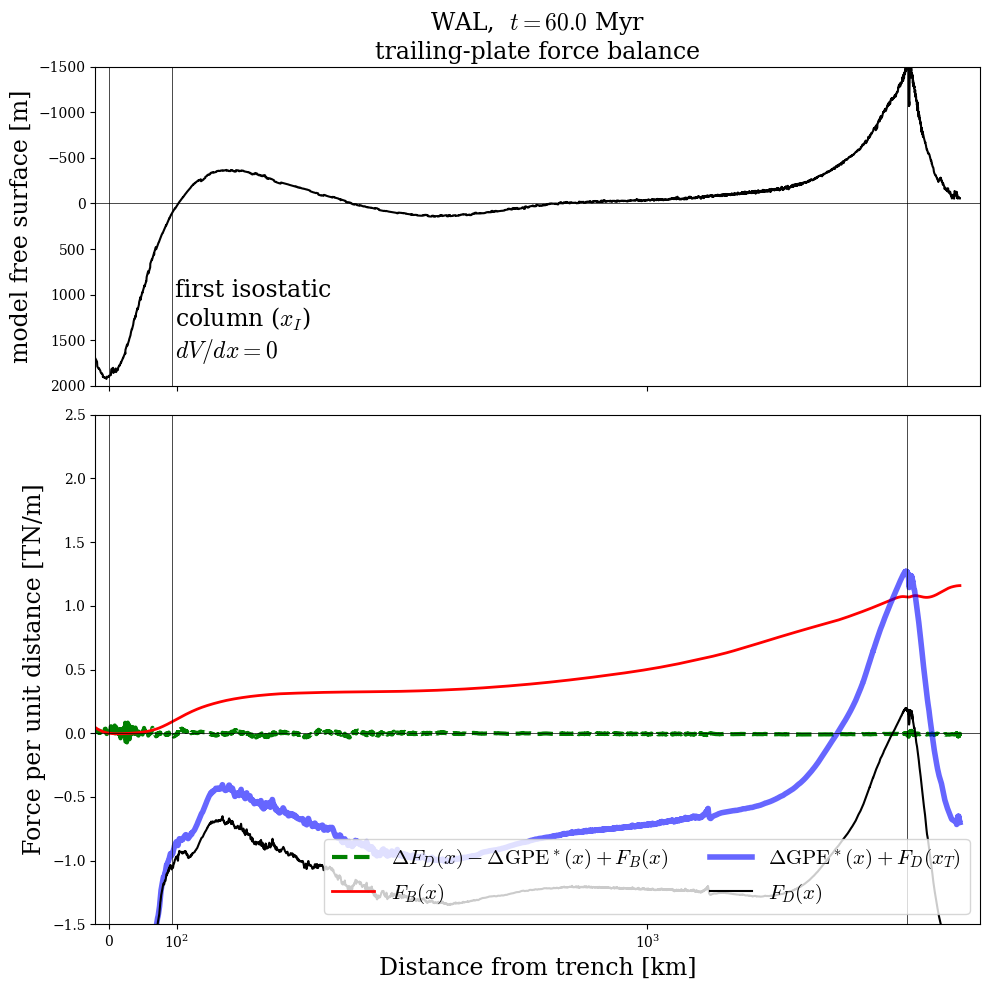

In [151]:
# § 8.2 — Interesting form of the force balance, with topography panel
#
#   Delta F_D(x) - Delta GPE*(x) + F_B(x) ~ 0
#
# In the mirrored frame, the natural deltas are (current - trench).

Sxx = np.trapz(-p + txx, z, axis=0)     # int sigma_xx dz
Szz = np.trapz(-p + tzz, z, axis=0)     # int sigma_zz dz   (= -GPE*)

#delta_Fd  = Fd  - Fd[tindx]
#delta_Szz = Szz - Szz[tindx]            # = -Delta GPE*  (we plot this directly)

# Trench-reference window: average ±N km around the picked trench column.                                                                                                                            
TRENCH_REF_HW_KM = 25                                  # half-width in km                                                                                                                            
WIN_T = max(1, int(TRENCH_REF_HW_KM * 1000 / DX))      # in grid points                                                                                                                              
                                                                                                                                                                                        
#delta_Fd = Fd  -  col_avg(Fd, tindx, win=WIN_T)
#delta_Szz = Szz - col_avg(Szz,  tindx, win=WIN_T)
delta_Fd = Fd  
delta_Szz = Szz - col_avg(Szz,  tindx, win=WIN_T) - col_avg(Fd, tindx, win=WIN_T)

# Pseudo-topography from V's gradient, aligned to actual at x_I
topo_actual     = fs[0, :]
topo_pseudo     = -dVdx / (rho_m * g)
topo_pseudo_ref = topo_pseudo - topo_pseudo[xi_indx] - topo_actual[xi_indx]

xkm = (x - tloc) * 1e-3

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True,
                                gridspec_kw={"height_ratios": [1.25, 2]})

ax1.plot(xkm, -fs[0, :], color="k", lw=1.5, alpha=1,                                                                                                                                               
         label="model free\nsurface")                                                                                                                                                              
                                                                                                                                                                                                   
ax1.axhline(0, color="k", lw=0.5)                                                                                                                                                                  
ax1.axvline(0, color="k", lw=0.5)
ax1.axvline((xi_loc - tloc)*1e-3, color="k", lw=0.5)
ax1.axvline((rloc - tloc)*1e-3, color="k", lw=0.5)  
ax1.set_ylim(2000, -1500)                       # was (-2000, 1000)                                                                                                                                
ax1.set_ylabel("model free surface [m]", fontsize=17)
#ax1.legend(loc="lower right", fontsize=17)      # ncol=2 dropped — only one curve                                                                                                                  
ax1.text((xi_loc - tloc)*1e-3 + 5, 1700,        # was y = -1700                                                                                                                                    
           "first isostatic\ncolumn (" + r"$x_I$" + ")\n" + r"$dV/dx = 0$",                                                                                                                          
           fontsize=17)  

# --- Bottom: ΔF_D - ΔGPE* + F_B ---

ax2.plot(xkm, (delta_Fd + delta_Szz + FB) * 1e-12,
           color="g", ls="--", lw=3,                                                                                                                                      
           label=r"$ \Delta F_D(x) - \Delta\mathrm{GPE}^*(x)  + F_B(x)$")
                                                                                                                                                                          
ax2.plot(xkm, FB * 1e-12, color="red", lw=2,                                                                                                                            
           label=r"$F_B(x)$")                                                                                                                                             
                                                                                                                                                                          
ax2.plot(xkm, -delta_Szz * 1e-12, color="b", lw=4, alpha=0.6,                                                                                                           
           label=r"$\Delta\mathrm{GPE}^*(x) + F_D(x_T)$")
                                                                                                                                                                          
ax2.plot(xkm, delta_Fd * 1e-12, color="k", ls="-", lw=1.5,                                                                                                              
           label=r"$F_D(x)$")


ax2.axhline(0, color="k", lw=0.5)
ax2.axvline(0, color="k", lw=0.5)
ax2.axvline((xi_loc - tloc)*1e-3, color="k", lw=0.5)
ax2.axvline((rloc - tloc)*1e-3, color="k", lw=0.5)  
ax2.set_xlabel("Distance from trench [km]", fontsize=17)
ax2.set_ylabel("Force per unit distance [TN/m]", fontsize=17)
ax2.set_xlim(-20, 3500)
ax2.set_ylim(-1.5, 2.5)
ax2.legend(loc="lower right", fontsize=15, ncol=2)
ax1.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr\n"                                                                                                                                            
                r"trailing-plate force balance"                                                                                                                                                     ,
                fontsize=17)


ax1.set_xscale("symlog", linthresh=250, linscale=0.25)                                                                                                                                                  
ax2.set_xscale("symlog", linthresh=250, linscale=0.25)                                                                                                                                                  
#ax2.set_xlim(-20, 3500) 

fig.savefig(figures_dir / f"force_balance_FD_abs_GPE_FB_{MODEL_KEY}_t{TIMESTEP_INDEX}.png",                                                                                                              
              bbox_inches="tight", dpi=220)

fig.tight_layout()
plt.show()

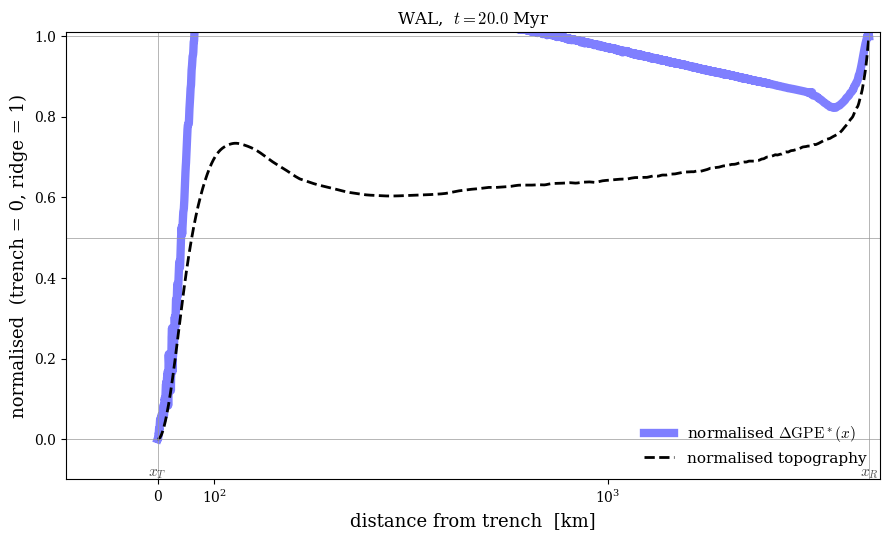

In [195]:
# Both ΔGPE*(x) and topography(x) plotted on the same axis, each linearly
# rescaled so that
#   value(x_T) = 0   (trench)
#   value(x_R) = 1   (ridge)
#
# Lets you eyeball how closely the GPE column-integral tracks surface
# elevation as you move from trench to ridge.

# --- Locate the ridge ----------------------------------------------------
ridge_loc, ridge_indx = find_ridge_x(
    x, fs[0, :], tloc, seaward_sign=SEAWARD_SIGN,
    buffer_km=200, smooth_km=50,
)

# --- Compute ΔGPE*(x) and topography(x) ---------------------------------
Szz       = np.trapz(-p + tzz, z, axis=0)
delta_GPE = Szz[tindx] - Szz                         # (nx,)
topo      = gaussian_filter(fs[0, :], 50)                                  # (nx,)  positive up

# --- Trench-to-ridge normalisation: trench → 0, ridge → 1 ---------------
def norm_TR(arr, i_T, i_R):
    a_T, a_R = arr[i_T], arr[i_R]
    return (arr - a_T) / (a_R - a_T)

dGPE_norm = norm_TR(delta_GPE, tindx, ridge_indx)
topo_norm = norm_TR(topo,      tindx, ridge_indx)

# Restrict to the segment between trench and ridge
xkm  = (x - tloc) * 1e-3
i_lo = min(tindx, ridge_indx)
i_hi = max(tindx, ridge_indx) + 1
seg  = slice(i_lo, i_hi)

# --- Figure --------------------------------------------------------------
fig, ax = plt.subplots(figsize=(9, 5.5))

ax.plot(xkm[seg], dGPE_norm[seg],
        color="b", lw=6, alpha=0.5,
        label=r"normalised $\Delta\mathrm{GPE}^*(x)$")
ax.plot(xkm[seg], topo_norm[seg],
        color="k", lw=2.0, ls="--",
        label="normalised topography")

ax.axhline(0, color="0.6", lw=0.5)
ax.axhline(0.5, color="0.6", lw=0.5)
ax.axhline(1, color="0.6", lw=0.5)
ax.axvline(0, color="0.6", lw=0.5)
ax.axvline((ridge_loc - tloc) * 1e-3, color="0.6", lw=0.5)

# Endpoint annotations
ax.text(0,                         -0.07, r"$x_T$",
        ha="center", va="top", color="0.3", fontsize=11)
ax.text((ridge_loc - tloc) * 1e-3, -0.07, r"$x_R$",
        ha="center", va="top", color="0.3", fontsize=11)

ax.set_xlabel("distance from trench  [km]", fontsize=13)
ax.set_ylabel("normalised  (trench = 0, ridge = 1)", fontsize=13)
ax.set_ylim(-0.1, 1.01)
ax.legend(frameon=False, loc="lower right", fontsize=11)
#ax.grid(alpha=0.25)

ax.set_title(f"{MODEL_KEY},  $t = {t_yr/1e6:.1f}$ Myr", fontsize=12)


ax.set_xscale("symlog", linthresh=250, linscale=0.25)                                                                                                                                                  
#ax2.set_xlim(-20, 3500) 

fig.tight_layout()

figures_dir = Path("figures"); figures_dir.mkdir(exist_ok=True)
fig.savefig(figures_dir / f"dGPE_topo_normalised_vs_x_{MODEL_KEY}_t{TIMESTEP_INDEX}.png",
            bbox_inches="tight", dpi=220)
plt.show()



In [153]:
FB[tindx]

0.0